# Laboratorio 4, Parte 2: Modelos con datos geoespaciales
**CC3084 Data Science | Universidad del Valle de Guatemala | Semestre II 2026**

**Integrantes:**
- Roberto Barreda (23354)
- Javier España (23361)
- Ángel Esquit (23221)

## 1. Entorno de trabajo

Importamos las librerías y definimos las carpetas de entrada y salida.

In [1]:
import json
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from pyproj import Transformer
from scipy import ndimage

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GroupKFold, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from matplotlib.colors import BoundaryNorm, ListedColormap
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.seterr(divide='ignore', invalid='ignore')

DIR_DATOS = '../data'
DIR_SALIDA = '../outputs'

print('Entorno configurado correctamente.')
print(f'rasterio: {rasterio.__version__} | pandas: {pd.__version__} | numpy: {np.__version__}')


Entorno configurado correctamente.
rasterio: 1.5.1 | pandas: 2.3.3 | numpy: 2.4.4


## 2. Configuración: fechas, bandas y umbrales

Usamos las mismas 11 fechas por lago y las mismas 9 bandas de Sentinel-2 L2A que en la Parte I, para que los resultados de ambas partes sean comparables.

In [2]:
BANDAS = ['B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12']
RESOLUCION_M = 20
EPS_REFLECTANCIA = 1e-4

UMBRAL_ALTO = 30.0
UMBRAL_FAI = 0.08

catalogo_atitlan = {
    '2025-01-18': (0.02, 'Sentinel-2B'), '2025-04-13': (0.54, 'Sentinel-2C'),
    '2025-05-13': (4.37, 'Sentinel-2C'), '2025-07-17': (3.57, 'Sentinel-2A'),
    '2025-11-21': (3.15, 'Sentinel-2A'), '2025-12-29': (3.17, 'Sentinel-2C'),
    '2026-02-12': (0.04, 'Sentinel-2B'), '2026-03-24': (3.17, 'Sentinel-2B'),
    '2026-04-13': (0.01, 'Sentinel-2B'), '2026-04-28': (4.96, 'Sentinel-2C'),
    '2026-07-22': (4.02, 'Sentinel-2B'),
}
catalogo_amatitlan = {
    '2025-01-28': (0.06, 'Sentinel-2B'), '2025-04-15': (0.09, 'Sentinel-2A'),
    '2025-04-28': (1.03, 'Sentinel-2B'), '2025-11-24': (0.50, 'Sentinel-2B'),
    '2026-01-08': (0.77, 'Sentinel-2C'), '2026-02-02': (0.39, 'Sentinel-2B'),
    '2026-02-07': (0.02, 'Sentinel-2C'), '2026-03-29': (0.01, 'Sentinel-2C'),
    '2026-04-13': (0.09, 'Sentinel-2B'), '2026-04-28': (4.96, 'Sentinel-2C'),
    '2026-06-19': (13.00, 'Sentinel-2A'),
}

LAGOS = {
    'atitlan': {'catalogo': catalogo_atitlan},
    'amatitlan': {'catalogo': catalogo_amatitlan},
}
for nombre, cfg in LAGOS.items():
    cfg['fechas'] = sorted(cfg['catalogo'])

def ruta_tif(lago, fecha):
    return os.path.join(DIR_DATOS, lago, f'{lago}_{fecha}.tif')


### Imágenes disponibles en disco

In [3]:
filas = []
for lago, cfg in LAGOS.items():
    for fecha in cfg['fechas']:
        filas.append({'lago': lago, 'fecha': fecha, 'disponible': os.path.exists(ruta_tif(lago, fecha))})
disponibilidad = pd.DataFrame(filas)
n_disp = disponibilidad['disponible'].sum()
print(f'{n_disp} de {len(disponibilidad)} imagenes disponibles en {DIR_DATOS}/')
display(disponibilidad.pivot(index='fecha', columns='lago', values='disponible').fillna(False))


22 de 22 imagenes disponibles en ../data/


lago,amatitlan,atitlan
fecha,,
2025-01-18,False,True
2025-01-28,True,False
2025-04-13,False,True
2025-04-15,True,False
2025-04-28,True,False
2025-05-13,False,True
2025-07-17,False,True
2025-11-21,False,True
2025-11-24,True,False


## 3. Funciones de cálculo espectral

Funciones para leer la reflectancia de cada GeoTIFF, calcular NDVI, NDWI, NDCI y FAI, y estimar la clorofila-$a$ con el mismo algoritmo de Sentinel Hub / CyanoLakes que usamos en la Parte I.

In [4]:
def leer_reflectancia(ruta):
    with rasterio.open(ruta) as src:
        datos = src.read().astype(np.float32)
        transform = src.transform
        crs = str(src.crs)
    if np.nanmax(datos) > 1.5:
        datos = datos / 10000.0
    sin_dato = np.all(~np.isfinite(datos), axis=0) | np.all(datos == 0, axis=0)
    bandas = {nombre: datos[i] for i, nombre in enumerate(BANDAS)}
    return bandas, transform, crs, sin_dato

def indice_normalizado(a, b):
    denominador = a + b
    with np.errstate(divide='ignore', invalid='ignore'):
        cociente = (a - b) / denominador
    return np.where(np.abs(denominador) < EPS_REFLECTANCIA, np.nan, cociente)

def indice_cianobacteria(b):
    evaluable = (b['B04'] > 0) & (b['B05'] > 0)
    ndci = np.where(evaluable, indice_normalizado(b['B05'], b['B04']), np.nan)
    chla = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071
    return ndci, np.clip(chla, 0, 500.0)

def indice_algas_flotantes(b):
    return b['B07'] - b['B04'] - (b['B8A'] - b['B04']) * (783 - 665) / (865 - 665)


## 4. Huella de agua, coordenadas y distancia a la orilla

Cargamos las huellas estables de agua (`outputs/<lago>_huella.npz`) y sus metadatos (`outputs/<lago>_meta.json`) generados en la Parte I. Con `ndimage.distance_transform_edt` calculamos, para cada píxel, la distancia en metros hasta la orilla más cercana.

In [5]:
def cargar_huella(lago):
    with np.load(os.path.join(DIR_SALIDA, f'{lago}_huella.npz')) as datos:
        huella = datos['huella']
    with open(os.path.join(DIR_SALIDA, f'{lago}_meta.json'), encoding='utf-8') as fh:
        meta = json.load(fh)
    distancia_orilla_m = ndimage.distance_transform_edt(huella) * RESOLUCION_M
    return huella, meta, distancia_orilla_m

_TRANSFORMERS = {}
def a_lonlat(x, y, crs):
    if crs not in _TRANSFORMERS:
        _TRANSFORMERS[crs] = Transformer.from_crs(crs, 'EPSG:4326', always_xy=True)
    return _TRANSFORMERS[crs].transform(x, y)

for lago in LAGOS:
    huella, meta, dist_orilla = cargar_huella(lago)
    print(f'{lago:10s}: {huella.sum()} pixeles validos | CRS: {meta["crs"]} | Distancia max a orilla: {dist_orilla.max():.1f} m')


atitlan   : 301936 pixeles validos | CRS: EPSG:32615 | Distancia max a orilla: 3667.4 m
amatitlan : 34436 pixeles validos | CRS: EPSG:32615 | Distancia max a orilla: 1029.6 m


## 5. Ejercicio 1: Preparación de los datos para Machine Learning

### 1.1 y 1.2 Construcción del conjunto de datos georreferenciado

Cada fila del dataset es un píxel de 20 por 20 metros que cae dentro del espejo de agua estable del lago. Por cada píxel guardamos:

- Coordenadas proyectadas (`x_utm`, `y_utm` en EPSG:32615) y geográficas (`lon`, `lat` en WGS 84).
- Fecha de la toma y lago al que pertenece.
- Reflectancia de las 9 bandas: `B02`, `B03`, `B04`, `B05`, `B07`, `B08`, `B8A`, `B11`, `B12`.
- Índices derivados: NDVI, NDWI, NDCI, Chl-$a$ y FAI.
- Distancia a la orilla en metros (`distancia_orilla_m`).

In [6]:
def construir_tabla_fecha(lago, fecha, huella, distancia_orilla_m):
    ruta = ruta_tif(lago, fecha)
    if not os.path.exists(ruta):
        return None

    bandas, transform, crs, sin_dato = leer_reflectancia(ruta)
    ndci, chla = indice_cianobacteria(bandas)
    fai = indice_algas_flotantes(bandas)
    ndvi = indice_normalizado(bandas['B08'], bandas['B04'])
    ndwi = indice_normalizado(bandas['B03'], bandas['B08'])

    valido = huella & ~sin_dato & np.isfinite(chla)
    filas_px, cols_px = np.where(valido)
    if len(filas_px) == 0:
        return None

    xs, ys = rasterio.transform.xy(transform, filas_px, cols_px, offset='center')
    xs, ys = np.asarray(xs), np.asarray(ys)
    lons, lats = a_lonlat(xs, ys, crs)

    tabla = pd.DataFrame({
        'lago': lago,
        'fecha': pd.to_datetime(fecha),
        'fila_px': filas_px,
        'col_px': cols_px,
        'x_utm': xs,
        'y_utm': ys,
        'lon': lons,
        'lat': lats,
        'distancia_orilla_m': distancia_orilla_m[filas_px, cols_px],
    })
    for banda in BANDAS:
        tabla[banda] = bandas[banda][filas_px, cols_px]
    tabla['ndvi'] = ndvi[filas_px, cols_px]
    tabla['ndwi'] = ndwi[filas_px, cols_px]
    tabla['ndci'] = ndci[filas_px, cols_px]
    tabla['chla'] = chla[filas_px, cols_px]
    tabla['fai'] = fai[filas_px, cols_px]
    return tabla


In [7]:
ruta_csv_existente = os.path.join(DIR_SALIDA, 'dataset_ml_parte2.csv')

if os.path.exists(ruta_csv_existente):
    print('Cargando dataset preprocesado desde outputs/dataset_ml_parte2.csv...')
    df_pixeles = pd.read_csv(ruta_csv_existente, parse_dates=['fecha'])
    print(f'Dataset cargado exitosamente: {len(df_pixeles):,} observaciones.')
else:
    print('Extrayendo observaciones desde los GeoTIFFs...')
    tablas = []
    for lago, cfg in LAGOS.items():
        huella, meta, distancia_orilla_m = cargar_huella(lago)
        for fecha in cfg['fechas']:
            nubosidad, satelite = cfg['catalogo'][fecha]
            tabla = construir_tabla_fecha(lago, fecha, huella, distancia_orilla_m)
            if tabla is not None:
                tabla['nubosidad_pct'] = nubosidad
                tabla['satelite'] = satelite
                tablas.append(tabla)
    df_pixeles = pd.concat(tablas, ignore_index=True)
    print(f'Total observaciones extraidas inicialmente: {len(df_pixeles):,} filas.')


Cargando dataset preprocesado desde outputs/dataset_ml_parte2.csv...


Dataset cargado exitosamente: 3,321,327 observaciones.


### 1.3 Control de calidad y eliminación de observaciones no válidas

1. **Límites del lago.** Solo píxeles dentro de la huella de agua estable (`*_huella.npz`); quedan fuera la tierra y las orillas secas.
2. **Píxeles sin dato.** Se quitan NoData, ceros de reflectancia y píxeles no evaluables por sombra de montaña o nubes residuales.
3. **Fechas poco confiables.** Se descartan las fechas con menos del 70% de cobertura válida (`Confiable == False` en `indices_<lago>.csv`). El único caso es Atitlán 2025-01-18, con 23% de huella utilizable.

In [8]:
if 'Confiable' not in df_pixeles.columns:
    confiabilidad = pd.concat([
        pd.read_csv(os.path.join(DIR_SALIDA, 'indices_atitlan.csv'), parse_dates=['Fecha']),
        pd.read_csv(os.path.join(DIR_SALIDA, 'indices_amatitlan.csv'), parse_dates=['Fecha']),
    ])[['Lago', 'Fecha', 'Confiable', 'Nubosidad_pct']]

    n_antes = len(df_pixeles)
    df_pixeles = df_pixeles.merge(
        confiabilidad, left_on=['lago', 'fecha'], right_on=['Lago', 'Fecha'], how='left'
    ).drop(columns=['Lago', 'Fecha'])
    df_pixeles = df_pixeles[df_pixeles['Confiable'].fillna(True)].copy()
    n_descartadas = n_antes - len(df_pixeles)
    print(f'Observaciones descartadas por cobertura no confiable (<70%): {n_descartadas:,}')

print(f'Observaciones validas conservadas para Machine Learning: {len(df_pixeles):,}')


Observaciones validas conservadas para Machine Learning: 3,321,327


### 1.4 Conteos, tipos de variable y datos faltantes

In [9]:
print(f'Total de observaciones validas: {len(df_pixeles):,}')

print('\nConteo por lago')
print(df_pixeles['lago'].value_counts())

print('\nConteo por lago y fecha')
display(df_pixeles.groupby(['lago', 'fecha']).size().unstack(level=0).fillna(0).astype(int))

resumen_calidad = pd.DataFrame({
    'Tipo de Dato': df_pixeles.dtypes.astype(str),
    'Valores No Nulos': df_pixeles.notna().sum(),
    'Porcentaje Faltante (%)': (df_pixeles.isna().mean() * 100).round(3)
})
print('\nTipos de variable y datos faltantes')
display(resumen_calidad)


Total de observaciones validas: 3,321,327

Conteo por lago
lago
atitlan      2942535
amatitlan     378792
Name: count, dtype: int64

Conteo por lago y fecha


lago,amatitlan,atitlan
fecha,,
2025-01-28,34436,0
2025-04-13,0,301936
2025-04-15,34436,0
2025-04-28,34436,0
2025-05-13,0,301926
2025-07-17,0,301841
2025-11-21,0,287610
2025-11-24,34436,0
2025-12-29,0,284979



Tipos de variable y datos faltantes


,Tipo de Dato,Valores No Nulos,Porcentaje Faltante (%)
lago,object,3321327,0.000
fecha,datetime64[ns],3321327,0.000
fila_px,int64,3321327,0.000
col_px,int64,3321327,0.000
x_utm,float64,3321327,0.000
y_utm,float64,3321327,0.000
lon,float64,3321327,0.000
lat,float64,3321327,0.000
distancia_orilla_m,float64,3321327,0.000
B02,float64,3321327,0.000


### 1.5 Análisis exploratorio

Estadísticos descriptivos y distribuciones de las bandas y los índices que nos interesan.

In [10]:
variables_eda = ['chla', 'ndci', 'ndvi', 'ndwi', 'fai', 'distancia_orilla_m'] + BANDAS
display(df_pixeles[variables_eda].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4))


,count,mean,std,min,25%,50%,75%,max
chla,3321327.0,5.1939,10.4700,0.0000,2.8843,4.0202,4.5787,500.0000
ndci,3321327.0,0.0020,0.1477,-0.9783,-0.0424,-0.0026,0.0375,0.9592
ndvi,3317523.0,-0.0924,0.9489,-72.0000,-0.1079,-0.0417,0.0034,84.4998
ndwi,3321327.0,0.4523,0.2291,-54.4000,0.3000,0.4279,0.5616,32.8001
fai,3321327.0,0.0010,0.0051,-0.0540,-0.0002,0.0005,0.0012,0.2952
distancia_orilla_m,3321327.0,1196.9071,959.8231,20.0000,353.8361,963.3276,1892.8286,3667.4242
B02,3321327.0,0.0274,0.0220,0.0029,0.0165,0.0272,0.0325,1.5171
B03,3321327.0,0.0238,0.0232,0.0030,0.0135,0.0203,0.0261,1.3823
B04,3321327.0,0.0125,0.0201,0.0000,0.0044,0.0094,0.0154,1.3125
B05,3321327.0,0.0148,0.0255,0.0001,0.0041,0.0094,0.0166,1.4183


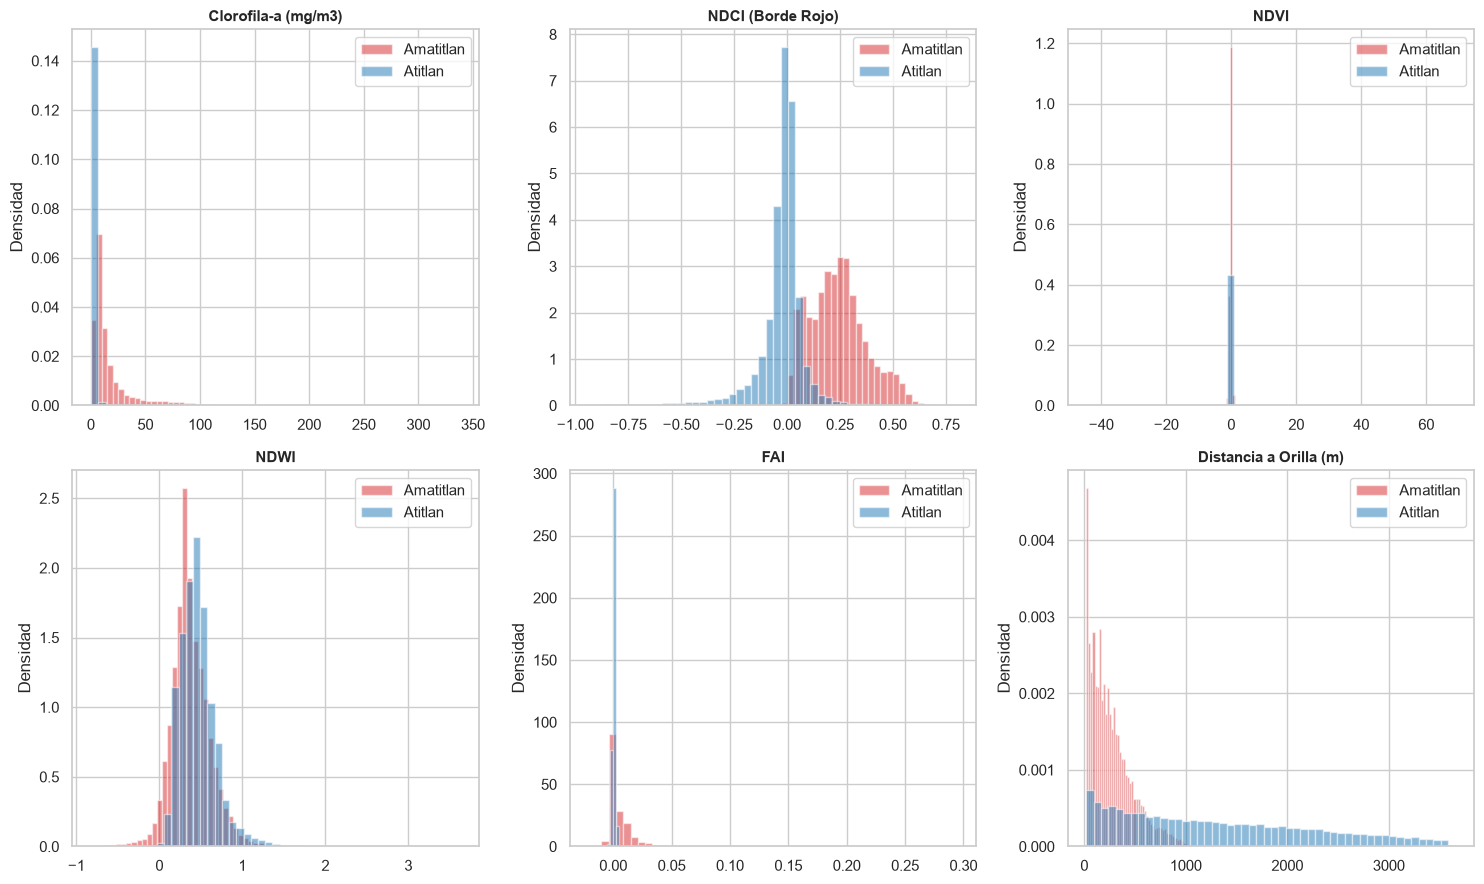

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
cols_plot = ['chla', 'ndci', 'ndvi', 'ndwi', 'fai', 'distancia_orilla_m']
titulos = ['Clorofila-a (mg/m3)', 'NDCI (Borde Rojo)', 'NDVI', 'NDWI', 'FAI', 'Distancia a Orilla (m)']

for ax, col, tit in zip(axes.flat, cols_plot, titulos):
    for lago, color in [('amatitlan', 'tab:red'), ('atitlan', 'tab:blue')]:
        sub = df_pixeles[df_pixeles['lago'] == lago][col].dropna()
        if len(sub) > 50000:
            sub = sub.sample(50000, random_state=42)
        ax.hist(sub, bins=50, density=True, alpha=0.5, label=lago.capitalize(), color=color)
    ax.set_title(tit, fontsize=11, fontweight='bold')
    ax.set_ylabel('Densidad')
    ax.legend()

plt.tight_layout()
plt.show()


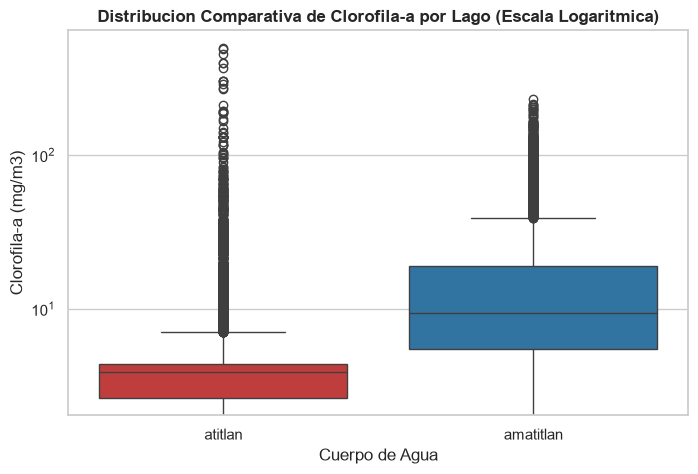

In [12]:
plt.figure(figsize=(8, 5))
sub_box = df_pixeles.sample(min(len(df_pixeles), 100000), random_state=42)
sns.boxplot(data=sub_box, x='lago', y='chla', palette=['tab:red', 'tab:blue'])
plt.yscale('log')
plt.title('Distribucion Comparativa de Clorofila-a por Lago (Escala Logaritmica)', fontsize=12, fontweight='bold')
plt.ylabel('Clorofila-a (mg/m3)')
plt.xlabel('Cuerpo de Agua')
plt.show()


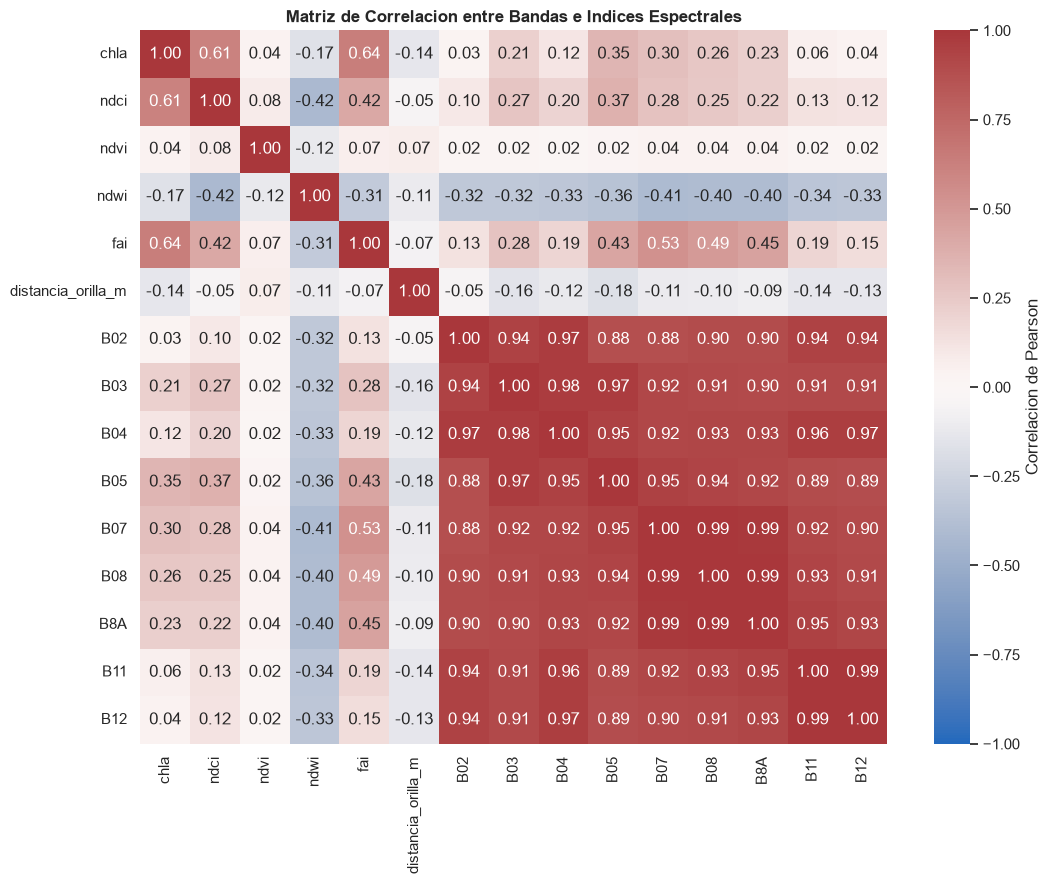

In [13]:
plt.figure(figsize=(11, 9))
sample_corr = df_pixeles[variables_eda].sample(min(len(df_pixeles), 100000), random_state=42)
matriz_corr = sample_corr.corr()
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Correlacion de Pearson'})
plt.title('Matriz de Correlacion entre Bandas e Indices Espectrales', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.6 Decisiones de preparación y limpieza

1. **Huella de agua estable en lugar de máscara por fecha.** Una máscara calculada fecha por fecha cambiaría de tamaño con la nubosidad y el oleaje, y el área analizada dejaría de ser comparable entre imágenes.
2. **Se eliminan sombras y ceros de reflectancia** ($B04 \le 0$ o $B05 \le 0$), frecuentes en las laderas de la caldera de Atitlán, que harían indeterminado el cociente del NDCI.
3. **Se descartan escenas con menos de 70% de cobertura.** Con tan poca área visible, los promedios quedan dominados por bordes de nube y no representan al lago.
4. **Clorofila acotada a $[0, 500]$ mg/m$^3$,** el rango de calibración del script de Sentinel Hub. Fuera de ahí los valores son artefactos de borde.

## 6. Ejercicio 2: Construcción de la variable respuesta

### 2.1 Variable respuesta binaria

Definimos `alta_cianobacteria` como:

$$y = \begin{cases} 1, & \text{si } \text{Chl-}a \ge 30\text{ mg/m}^3 \\ 0, & \text{si } \text{Chl-}a < 30\text{ mg/m}^3 \end{cases}$$

In [14]:
df_pixeles['alta_cianobacteria'] = (df_pixeles['chla'] >= UMBRAL_ALTO).astype(int)

conteo_clases = df_pixeles['alta_cianobacteria'].value_counts()
pct_clases = df_pixeles['alta_cianobacteria'].value_counts(normalize=True) * 100

resumen_y = pd.DataFrame({
    'Observaciones': conteo_clases,
    'Porcentaje (%)': pct_clases.round(2)
}, index=[0, 1])
resumen_y.index.name = 'Clase (alta_cianobacteria)'
display(resumen_y)


,Observaciones,Porcentaje (%)
Clase (alta_cianobacteria),,
0,3256123,98.04
1,65204,1.96


### 2.2 Por qué el punto de corte está en 30 mg/m$^3$

El umbral sale del esquema de niveles de alerta de la OMS para aguas recreativas:

- **Vigilancia (1 a 12 $\mu$g/L de Chl-$a$):** valores normales en lagos oligotróficos y mesotróficos, riesgo bajo.
- **Alerta 1 (12 a 24 $\mu$g/L):** riesgo moderado, con irritación dérmica y molestias gastrointestinales reportadas.
- **Alerta 2 (más de 24 $\mu$g/L, o natas visibles):** alta probabilidad de microcistinas y cilindrospermopsinas, con riesgo serio por contacto o ingestión.

Los 30 $\mu$g/L caen dentro de Alerta 2 y coinciden con el punto donde el algoritmo de CyanoLakes cambia su rampa de color de verdes a tonos de alarma. Marcan el nivel en que la floración ya es visible y sanitariamente relevante, no un simple aumento estadístico.

**Referencias:** World Health Organization (2021), *Guidelines on Recreational Water Quality, Vol. 1: Coastal and Fresh Waters*, cap. 5. Chorus, I. y Welker, M. (2021), *Toxic Cyanobacteria in Water*, 2a ed., CRC Press / WHO.

### 2.3 Distribución de la variable respuesta: global, por lago y por fecha

Prevalencia de alta presencia por lago


,total,positivos,prevalencia_pct
lago,,,
amatitlan,378792,58936,15.56
atitlan,2942535,6268,0.21



Prevalencia por lago y fecha


lago,amatitlan,atitlan
fecha,,
2025-01-28,6.07,NaN
2025-04-13,NaN,0.01
2025-04-15,1.90,NaN
2025-04-28,9.68,NaN
2025-05-13,NaN,0.01
2025-07-17,NaN,0.13
2025-11-21,NaN,1.00
2025-11-24,7.70,NaN
2025-12-29,NaN,0.28


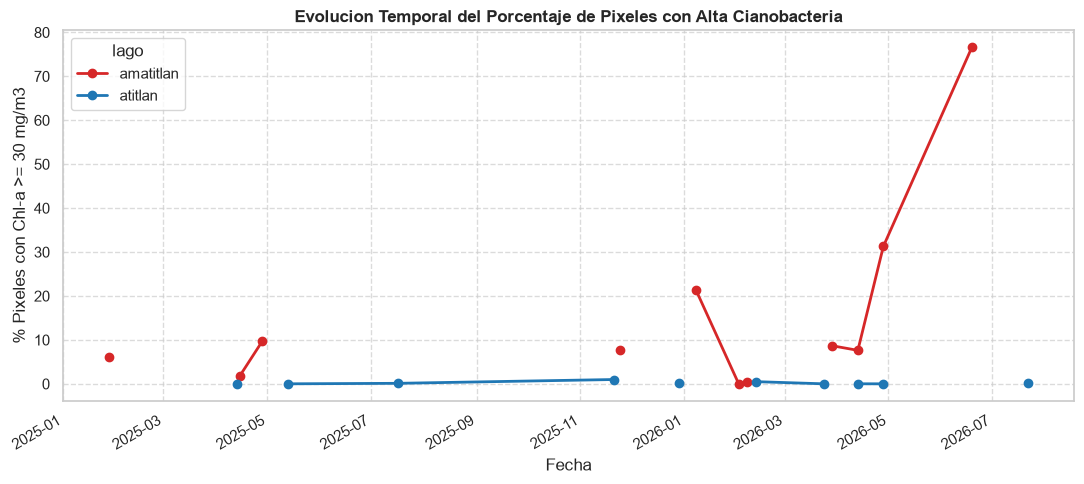

In [15]:
print('Prevalencia de alta presencia por lago')
prev_lago = df_pixeles.groupby('lago')['alta_cianobacteria'].agg(
    total='count',
    positivos='sum',
    prevalencia_pct=lambda x: x.mean() * 100
).round(2)
display(prev_lago)

print('\nPrevalencia por lago y fecha')
prev_temporal = df_pixeles.groupby(['lago', 'fecha'])['alta_cianobacteria'].agg(
    total='count',
    positivos='sum',
    pct_alta=lambda x: (x.mean() * 100)
).round(2)
display(prev_temporal.unstack(level=0)['pct_alta'])

fig, ax = plt.subplots(figsize=(11, 5))
evolucion = df_pixeles.groupby(['fecha', 'lago'])['alta_cianobacteria'].mean().mul(100).unstack()
evolucion.plot(ax=ax, marker='o', linewidth=2, color=['tab:red', 'tab:blue'])
ax.set_title('Evolucion Temporal del Porcentaje de Pixeles con Alta Cianobacteria', fontsize=12, fontweight='bold')
ax.set_ylabel('% Pixeles con Chl-a >= 30 mg/m3')
ax.set_xlabel('Fecha')
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 2.4 Desbalance de clases y qué implica para el modelado

In [16]:
n_neg = (df_pixeles['alta_cianobacteria'] == 0).sum()
n_pos = (df_pixeles['alta_cianobacteria'] == 1).sum()
ratio_desbalance = n_pos / n_neg
desbalance_inv = n_neg / n_pos

print(f'Clase 0 (Baja/Ausencia): {n_neg:,} observaciones ({n_neg/len(df_pixeles)*100:.2f}%)')
print(f'Clase 1 (Alta Presencia): {n_pos:,} observaciones ({n_pos/len(df_pixeles)*100:.2f}%)')
print(f'Razon Minoritaria / Mayoritaria: 1 : {desbalance_inv:.1f} (ratio = {ratio_desbalance:.4f})')


Clase 0 (Baja/Ausencia): 3,256,123 observaciones (98.04%)
Clase 1 (Alta Presencia): 65,204 observaciones (1.96%)
Razon Minoritaria / Mayoritaria: 1 : 49.9 (ratio = 0.0200)


**Qué implica este desbalance:**

1. **El Accuracy no sirve como métrica principal.** Predecir siempre la clase 0 acierta el 98.04% de las veces sin detectar una sola floración.
2. **Las funciones de pérdida ignoran la clase minoritaria.** Con 1.96% de positivos, sacrificarlos es el camino barato. Por eso usamos `class_weight='balanced'` en Regresión Logística y Random Forest, y `scale_pos_weight` en XGBoost.
3. **Nos guiamos por Recall, Precision, F1 y ROC-AUC** en lugar del Accuracy.
4. **El desbalance no es igual en los dos lagos:** 0.21% de positivos en Atitlán contra 15.56% en Amatitlán, así que un modelo entrenado con ambos aprende sobre todo del comportamiento de Amatitlán.

### 2.5 Variables que no podemos usar como predictoras

- **`chla`.** La respuesta es $y = \mathbb{1}(\text{Chl-}a \ge 30)$, así que incluirla equivaldría a leer el umbral.
- **`ndci`.** La clorofila se deriva del NDCI mediante $\text{Chl-}a = 826.57\,\text{NDCI}^3 - 176.43\,\text{NDCI}^2 + 19\,\text{NDCI} + 4.071$. Al ser una función determinista, incluirlo mete la respuesta por la puerta de atrás.

`B04` y `B05` sí se conservan: el NDCI se calcula con ellas, pero por separado no reconstruyen el umbral y son las que aportan la señal física del borde rojo.

In [17]:
VARIABLES_EXCLUIDAS = ['chla', 'ndci', 'alta_cianobacteria']
print('Variables excluidas del modelado predictivo:', VARIABLES_EXCLUIDAS)


Variables excluidas del modelado predictivo: ['chla', 'ndci', 'alta_cianobacteria']


## 7. Ejercicio 3: Selección y construcción de variables predictoras

### 3.1 y 3.2 Los 17 predictores y por qué los elegimos

| Variable | Categoría | Qué representa | Por qué puede ayudar |
|---|---|---|---|
| `B02` (Azul, 490 nm) | Espectral | Reflectancia en el azul | El agua limpia dispersa mucho azul; con floración los pigmentos lo absorben. |
| `B03` (Verde, 560 nm) | Espectral | Reflectancia en el verde | Es el reflejo característico del fitoplancton en superficie. |
| `B04` (Rojo, 665 nm) | Espectral | Pico de absorción de la clorofila | La clorofila absorbe fuerte aquí, lo que crea el contraste con el infrarrojo. |
| `B05` (Red Edge 1, 705 nm) | Espectral | Borde rojo | Es la banda más sensible a concentraciones altas de clorofila. |
| `B07` (Red Edge 3, 783 nm) | Espectral | Borde rojo lejano | Responde a material particulado y a floraciones en superficie. |
| `B08` (NIR, 842 nm) | Espectral | Infrarrojo cercano | El agua lo absorbe casi todo, así que cualquier biomasa flotante lo dispara. |
| `B8A` (NIR estrecho, 865 nm) | Espectral | Infrarrojo cercano angosto | Sirve de referencia para separar el fondo del agua de las natas superficiales. |
| `B11` (SWIR 1, 1610 nm) | Espectral | Infrarrojo de onda corta | Muy absorbido por agua pura; se mueve con la turbidez inorgánica. |
| `B12` (SWIR 2, 2190 nm) | Espectral | Infrarrojo de onda corta lejano | Ayuda a distinguir aerosoles, vapor de agua y sedimento denso. |
| `ndvi` | Índice | Índice de vegetación | Sube cuando hay biomasa flotante suficiente para comportarse como vegetación. |
| `ndwi` | Índice | Índice de agua | Separa el agua libre del agua cargada de materia orgánica. |
| `distancia_orilla_m` | Espacial | Distancia a la orilla en metros | Las zonas cerca de la costa reciben las descargas de nutrientes, como el río Villalobos en Amatitlán. |
| `x_utm`, `y_utm` | Espacial | Coordenadas en metros (UTM 15N) | Capturan los gradientes de este a oeste y de norte a sur dentro de cada lago. |
| `mes` | Temporal | Mes de la toma (1 a 12) | Recoge el ciclo anual de las floraciones. |
| `estacion_cod` | Temporal | Época seca (nov a abr) o lluviosa (may a oct) | La escorrentía de la época lluviosa arrastra nutrientes hacia el lago. |
| `indice_turbidez_swir` | Ingeniería | Razón $B11 / B08$ | Distingue turbidez por sedimento de turbidez por algas. |

Nota sobre `x_utm` y `y_utm`: al ser coordenadas, el modelo puede memorizar posiciones en lugar de aprender la señal espectral. Justamente por eso el ejercicio 6 valida con bloques espaciales, donde esas coordenadas ya no le sirven al modelo para hacer trampa.

### 3.3 Ingeniería de características

Construimos las variables temporales, la codificación de estación y la razón espectral de turbidez.

In [18]:
df_pixeles['mes'] = df_pixeles['fecha'].dt.month
df_pixeles['estacion'] = np.where(df_pixeles['mes'].isin([11, 12, 1, 2, 3, 4]), 'seca', 'lluviosa')
df_pixeles['estacion_cod'] = (df_pixeles['estacion'] == 'lluviosa').astype(int)
df_pixeles['indice_turbidez_swir'] = df_pixeles['B11'] / df_pixeles['B08'].replace(0, np.nan)
df_pixeles['indice_turbidez_swir'] = df_pixeles['indice_turbidez_swir'].fillna(0.0).clip(0, 50.0)

VARIABLES_PREDICTORAS = BANDAS + [
    'ndvi', 'ndwi', 'distancia_orilla_m', 'x_utm', 'y_utm',
    'mes', 'estacion_cod', 'indice_turbidez_swir'
]

print(f'Total variables predictoras seleccionadas: {len(VARIABLES_PREDICTORAS)}')
print(VARIABLES_PREDICTORAS)


Total variables predictoras seleccionadas: 17
['B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12', 'ndvi', 'ndwi', 'distancia_orilla_m', 'x_utm', 'y_utm', 'mes', 'estacion_cod', 'indice_turbidez_swir']


### Guardado del dataset procesado

In [19]:
ruta_salida_dataset = os.path.join(DIR_SALIDA, 'dataset_ml_parte2.csv')
if not os.path.exists(ruta_salida_dataset):
    df_pixeles.to_csv(ruta_salida_dataset, index=False)
    print(f'Dataset guardado exitosamente en: {ruta_salida_dataset}')
else:
    print(f'Dataset ya se encuentra persistido en: {ruta_salida_dataset}')
print(f'Dimensiones finales: {df_pixeles.shape[0]:,} filas x {df_pixeles.shape[1]} columnas')


Dataset ya se encuentra persistido en: ../outputs\dataset_ml_parte2.csv
Dimensiones finales: 3,321,327 filas x 32 columnas


## 8. Ejercicio 4: Construcción de los modelos

### 4.1 a 4.4 Configuración y división de datos

Tres modelos de clasificación:

1. **Regresión Logística:** imputación por mediana, `StandardScaler`, L2 con $C=1.0$ y `class_weight='balanced'`.
2. **Random Forest:** `n_estimators=80`, `max_depth=12`, `class_weight='balanced'`, `max_samples=0.20`.
3. **XGBoost:** `tree_method='hist'`, `learning_rate=0.1`, `max_depth=6`, `scale_pos_weight = N_neg / N_pos`.

**Sobre la muestra.** Entrenar Random Forest sobre los 3.3 millones de píxeles cinco veces, una por fold espacial, no era viable en las máquinas del equipo. Usamos una muestra de 250,000 píxeles estratificada por lago y clase, que conserva la proporción de positivos y el peso relativo de cada lago. Todos los ejercicios de modelado usan esta misma muestra.

**División.** 70% entrenamiento y 30% prueba, estratificado por clase (`stratify=y`, `random_state=42`). Los tres modelos se evalúan sobre exactamente el mismo conjunto de prueba.

In [20]:
N_MUESTRA_ML = 250000
# Limpieza de nulos en predictores antes de muestreo
df_pixeles_clean = df_pixeles.dropna(subset=VARIABLES_PREDICTORAS + ['alta_cianobacteria']).copy()

if len(df_pixeles_clean) > N_MUESTRA_ML:
    df_ml = df_pixeles_clean.groupby(['lago', 'alta_cianobacteria'], group_keys=False).apply(
        lambda g: g.sample(frac=N_MUESTRA_ML/len(df_pixeles_clean), random_state=42),
        include_groups=False
    ).reset_index()
    df_ml = df_pixeles_clean.loc[df_ml['index'] if 'index' in df_ml else df_ml.index].copy()
else:
    df_ml = df_pixeles_clean.copy()

X = df_ml[VARIABLES_PREDICTORAS]
y = df_ml['alta_cianobacteria']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Dimensiones de entrenamiento: {X_train.shape[0]:,} muestras ({y_train.sum():,} positivas)')
print(f'Dimensiones de prueba (fijo): {X_test.shape[0]:,} muestras ({y_test.sum():,} positivas)')


Dimensiones de entrenamiento: 174,999 muestras (3,433 positivas)
Dimensiones de prueba (fijo): 75,000 muestras (1,472 positivas)


In [21]:
# 1. Regresion Logistica
print('Entrenando Regresion Logistica...')
t0 = time.time()
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
t_lr = time.time() - t0
print(f'Regresion Logistica entrenada en {t_lr:.2f} s')

# 2. Random Forest
print('Entrenando Random Forest...')
t0 = time.time()
rf_clf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        n_estimators=80,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        max_samples=0.20,
        random_state=42,
        n_jobs=-1
    ))
])
rf_clf.fit(X_train, y_train)
t_rf = time.time() - t0
print(f'Random Forest entrenado en {t_rf:.2f} s')

# 3. XGBoost
print('Entrenando XGBoost...')
t0 = time.time()
ratio_pos_peso = (len(y_train) - y_train.sum()) / max(1, y_train.sum())
xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio_pos_peso,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X_train, y_train)
t_xgb = time.time() - t0
print(f'XGBoost entrenado en {t_xgb:.2f} s')


Entrenando Regresion Logistica...


Regresion Logistica entrenada en 0.87 s
Entrenando Random Forest...


Random Forest entrenado en 0.75 s
Entrenando XGBoost...


XGBoost entrenado en 0.60 s


### 4.3 Por qué esos hiperparámetros

**Regresión Logística.** `StandardScaler` porque las bandas y los índices están en escalas distintas y sin normalizar las de valores grandes dominarían los coeficientes. `class_weight='balanced'` ($w_j = n / 2n_j$) es indispensable con 1.96% de positivos. `C=1.0` regulariza la fuerte colinealidad entre bandas.

**Random Forest.** Probamos `n_estimators` en 50, 80 y 150: de 80 en adelante las métricas ya no se movían. `max_depth=12` porque sin límite el modelo memorizaba ruido radiométrico. `min_samples_leaf=5` evita hojas de un solo píxel. `max_samples=0.20` mantiene la diversidad del ensamble y baja el costo de entrenamiento.

**XGBoost.** `scale_pos_weight = N_neg / N_pos` compensa el desbalance directamente en el gradiente. `learning_rate=0.1` con `n_estimators=100`: con tasas más altas el modelo se volvía inestable entre folds. `subsample` y `colsample_bytree` de 0.8 evitan que los árboles dependan siempre de las mismas bandas. `tree_method='hist'` hace viable entrenar con cientos de miles de filas.

## 9. Ejercicio 5: Evaluación de los modelos

### 5.1 Métricas, matrices de confusión y curvas ROC

Calculamos sobre el conjunto de prueba fijo: Accuracy, Precision, Recall, F1-Score, ROC-AUC y la matriz de confusión de cada modelo.

In [22]:
modelos = {
    'Regresion Logistica': lr_pipeline,
    'Random Forest': rf_clf,
    'XGBoost': xgb_clf
}

metricas_dict = {}
predicciones_prob = {}
predicciones_clase = {}

for nombre, mod in modelos.items():
    y_pred = mod.predict(X_test)
    y_proba = mod.predict_proba(X_test)[:, 1]
    
    predicciones_clase[nombre] = y_pred
    predicciones_prob[nombre] = y_proba
    
    metricas_dict[nombre] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Clase 1)': precision_score(y_test, y_pred, zero_division=0),
        'Recall (Clase 1)': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score (Clase 1)': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

df_metricas_test = pd.DataFrame(metricas_dict).T
print('Rendimiento sobre el conjunto de prueba (30%)')
display(df_metricas_test.round(4))


Rendimiento sobre el conjunto de prueba (30%)


,Accuracy,Precision (Clase 1),Recall (Clase 1),F1-Score (Clase 1),ROC-AUC
Regresion Logistica,0.9937,0.7582,0.9993,0.8623,0.9998
Random Forest,0.9891,0.6459,0.9851,0.7802,0.9991
XGBoost,0.9951,0.8092,0.9823,0.8874,0.9997


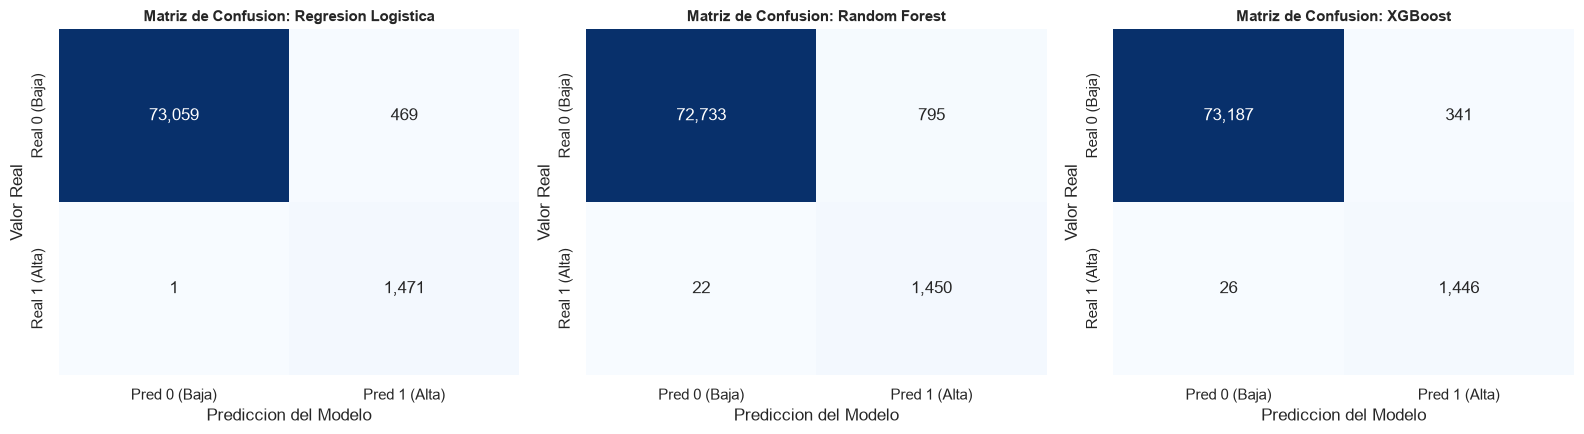

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (nombre, y_pred) in zip(axes, predicciones_clase.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred 0 (Baja)', 'Pred 1 (Alta)'],
                yticklabels=['Real 0 (Baja)', 'Real 1 (Alta)'])
    ax.set_title(f'Matriz de Confusion: {nombre}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Prediccion del Modelo')
    ax.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()


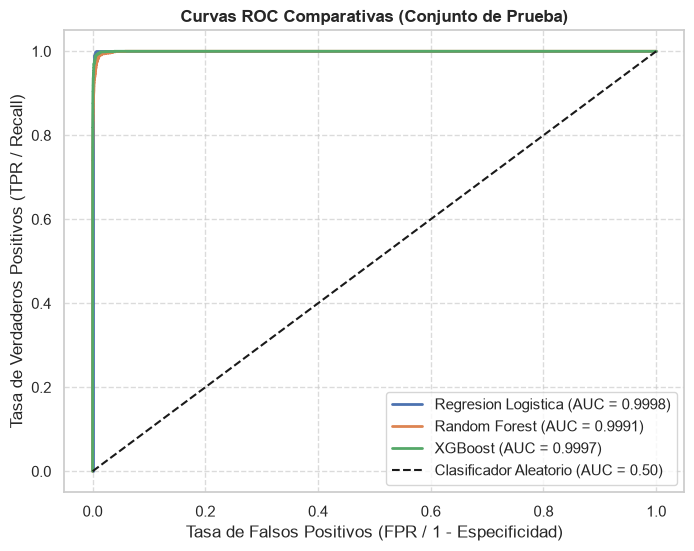

In [24]:
plt.figure(figsize=(8, 6))

for nombre, y_proba in predicciones_prob.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc_val:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.50)', linewidth=1.5)
plt.title('Curvas ROC Comparativas (Conjunto de Prueba)', fontsize=12, fontweight='bold')
plt.xlabel('Tasa de Falsos Positivos (FPR / 1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### 5.2 Comparación de los tres modelos

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Regresión Logística | 0.9937 | 0.7582 | 0.9993 | 0.8623 | 0.9998 |
| Random Forest | 0.9891 | 0.6459 | 0.9851 | 0.7802 | 0.9991 |
| XGBoost | 0.9951 | 0.8092 | 0.9823 | **0.8874** | 0.9997 |

**XGBoost es el mejor:** el F1 más alto y un Recall de 0.9823 con la mejor precisión del grupo. La **Regresión Logística** logra el Recall más alto (0.9993) pero con precisión 0.7582, porque para no perder positivos abre demasiado la frontera. **Random Forest** queda último con precisión 0.6459: `class_weight='balanced'` junto con `max_samples=0.20` lo vuelve muy agresivo con la clase minoritaria y marca bastante más área de la que corresponde.

Los tres superan 0.999 de ROC-AUC, o sea que ordenan bien los píxeles por riesgo. La diferencia está en dónde cae el umbral de 0.5, no en la capacidad de discriminar.

### 5.3 Qué error importa más

**Falso negativo (no detectar una floración real).** La gente sigue usando el agua mientras hay cianotoxinas, no se activan los planes de contingencia y el daño a la salud ya está hecho cuando la floración se detecta por otra vía. Es el error grave.

**Falso positivo (marcar floración donde no la hay).** Se manda a alguien a muestrear o se restringe el baño unos días sin necesidad. Cuesta tiempo y dinero y molesta al turismo, pero es reversible.

Como el costo de ambos errores es tan disparejo, priorizamos el **Recall**, con F1 y ROC-AUC como control para no premiar a un modelo que alcance sensibilidad alta marcando todo el lago, que es justo el problema de Random Forest.

## 10. Ejercicio 6: Validación espacial

### 6.1 Cuadrícula de 1 km en UTM 15N

Dos píxeles vecinos, separados por 20 metros, tienen casi la misma reflectancia. Si se reparten al azar entre entrenamiento y prueba, el modelo puede acertar por vecindad en lugar de por haber aprendido algo, y las métricas salen infladas. Para medir ese efecto dividimos cada lago en bloques de 1000 por 1000 metros sobre EPSG:32615, que trabaja en metros y cubre ambos lagos.

In [25]:
TAM_BLOQUE_M = 1000  # 1 km en metros UTM

df_pixeles['bloque_x'] = (df_pixeles['x_utm'] // TAM_BLOQUE_M).astype(int)
df_pixeles['bloque_y'] = (df_pixeles['y_utm'] // TAM_BLOQUE_M).astype(int)
df_pixeles['bloque_id'] = (
    df_pixeles['lago'] + '_bx' + df_pixeles['bloque_x'].astype(str) + '_by' + df_pixeles['bloque_y'].astype(str)
)

resumen_bloques = df_pixeles.groupby(['lago', 'bloque_id']).size().reset_index(name='n_pixeles')

print('Bloques espaciales de 1 km x 1 km')
print(f'Total de bloques unicos generados: {df_pixeles["bloque_id"].nunique()}')
print(f'Bloques en Lago Atitlan: {df_pixeles[df_pixeles["lago"]=="atitlan"]["bloque_id"].nunique()}')
print(f'Bloques en Lago Amatitlan: {df_pixeles[df_pixeles["lago"]=="amatitlan"]["bloque_id"].nunique()}')

print('\nObservaciones por bloque')
display(resumen_bloques.groupby('lago')['n_pixeles'].describe().round(1))


Bloques espaciales de 1 km x 1 km
Total de bloques unicos generados: 198


Bloques en Lago Atitlan: 165
Bloques en Lago Amatitlan: 33

Observaciones por bloque


,count,mean,std,min,25%,50%,75%,max
lago,,,,,,,,
amatitlan,33.0,11478.5,8580.4,11.0,4323.0,10634.0,18634.0,27500.0
atitlan,165.0,17833.5,9195.0,8.0,9481.0,24319.0,24997.0,25000.0


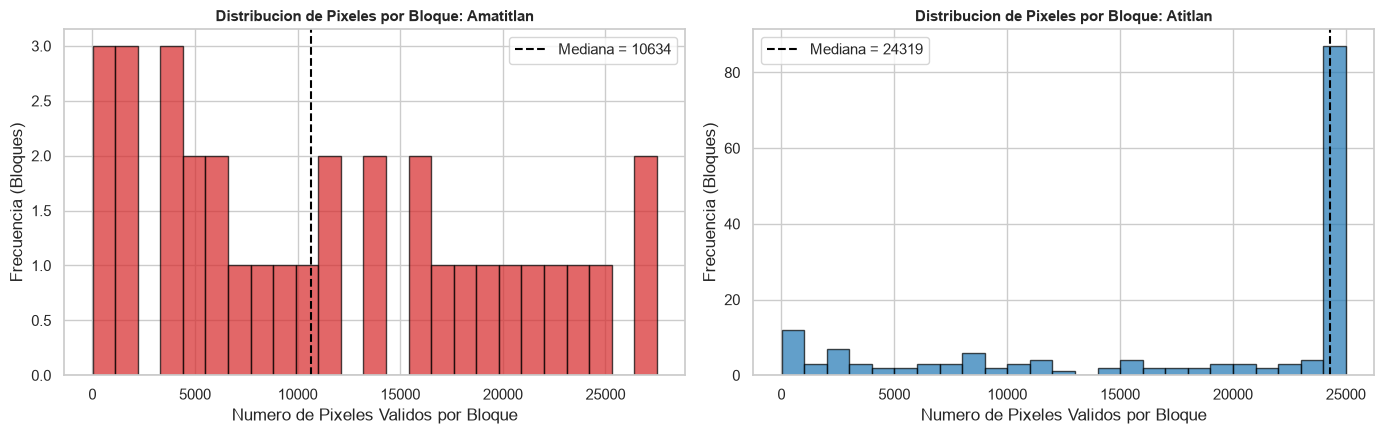

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, lago in zip(axes, ['amatitlan', 'atitlan']):
    sub_b = resumen_bloques[resumen_bloques['lago'] == lago]['n_pixeles']
    ax.hist(sub_b, bins=25, color='tab:blue' if lago=='atitlan' else 'tab:red', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribucion de Pixeles por Bloque: {lago.capitalize()}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Numero de Pixeles Validos por Bloque')
    ax.set_ylabel('Frecuencia (Bloques)')
    ax.axvline(sub_b.median(), color='black', linestyle='--', label=f'Mediana = {sub_b.median():.0f}')
    ax.legend()

plt.tight_layout()
plt.show()


In [27]:
# El enunciado pide evaluar si 1 km deja suficientes bloques con observaciones validas.
# Comparamos contra 500 m y 2 km antes de decidir.
N_SPLITS_ESPACIAL = 5
comparacion_tamanos = []

for tamano in (500, 1000, 2000):
    ids = (df_pixeles['lago'] + '_bx' + (df_pixeles['x_utm'] // tamano).astype(int).astype(str)
           + '_by' + (df_pixeles['y_utm'] // tamano).astype(int).astype(str))
    conteo = df_pixeles.groupby(ids).size()
    lago_bloque = df_pixeles.groupby(ids)['lago'].first()
    positivos_bloque = df_pixeles.groupby(ids)['alta_cianobacteria'].sum()

    comparacion_tamanos.append({
        'Tamano de bloque': f'{tamano} m',
        'Bloques totales': len(conteo),
        'Bloques Atitlan': int((lago_bloque == 'atitlan').sum()),
        'Bloques Amatitlan': int((lago_bloque == 'amatitlan').sum()),
        'Mediana px/bloque': int(conteo.median()),
        'Bloques < 100 px': int((conteo < 100).sum()),
        '% obs. en esos bloques': round(conteo[conteo < 100].sum() / len(df_pixeles) * 100, 3),
        'Bloques con algun positivo': int((positivos_bloque > 0).sum()),
        'Bloques Amatitlan por fold': round((lago_bloque == 'amatitlan').sum() / N_SPLITS_ESPACIAL, 1),
    })

print('Comparacion de tamanos de cuadricula')
display(pd.DataFrame(comparacion_tamanos).set_index('Tamano de bloque').T)

Comparacion de tamanos de cuadricula


Tamano de bloque,500 m,1000 m,2000 m
Bloques totales,668.000,198.000,64.000
Bloques Atitlan,571.000,165.000,51.000
Bloques Amatitlan,97.000,33.000,13.000
Mediana px/bloque,6245.000,21814.000,44371.000
Bloques < 100 px,16.000,4.000,2.000
% obs. en esos bloques,0.025,0.004,0.001
Bloques con algun positivo,557.000,189.000,63.000
Bloques Amatitlan por fold,19.400,6.600,2.600


**Por qué nos quedamos con 1 km.**

El conteo por bloque suma todas las fechas: un bloque de 1 km a 20 m de resolución tiene como máximo 2,500 píxeles por escena, y se acumulan las 10 u 11 fechas de cada lago.

- **500 m:** 668 bloques, pero solo 557 contienen algún positivo y 16 quedan bajo 100 observaciones. Demasiados grupos degenerados sin clase positiva.
- **2 km:** solo 64 bloques, y Amatitlán se queda con 13, o sea 2.6 por fold. Muy pocos para que la validación de ese lago signifique algo.
- **1 km:** 189 de los 198 bloques tienen al menos un positivo y solo 4 caen bajo 100 observaciones, que entre todos son el 0.004% de los datos.

El factor que decide es el tamaño de Amatitlán: con 13.77 km² de espejo de agua, cualquier cuadrícula más gruesa lo deja sin bloques suficientes para repartir entre 5 folds. Mantenemos 1 km. Los bloques diminutos son esquinas de la cuadrícula que apenas rozan la orilla y, por su peso despreciable, los dejamos dentro.

### 6.2 Asignación de bloques y mapa de la cuadrícula

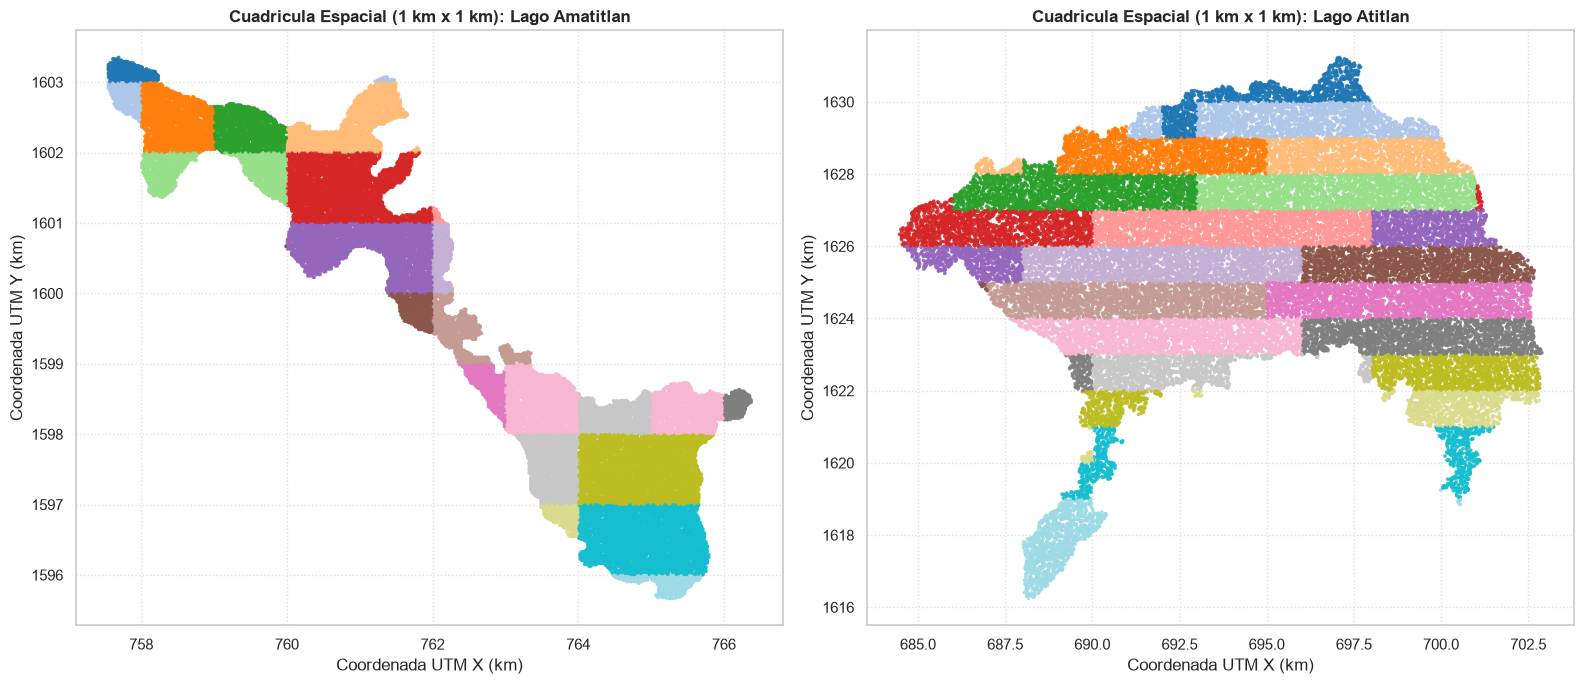

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, lago in zip(axes, ['amatitlan', 'atitlan']):
    sub = df_pixeles[df_pixeles['lago'] == lago]
    if len(sub) > 40000:
        sub_plot = sub.sample(40000, random_state=42)
    else:
        sub_plot = sub
        
    bloques_unicos = {b: i for i, b in enumerate(sub['bloque_id'].unique())}
    colores = sub_plot['bloque_id'].map(bloques_unicos)
    
    scatter = ax.scatter(
        sub_plot['x_utm'] / 1000.0,
        sub_plot['y_utm'] / 1000.0,
        c=colores,
        cmap='tab20',
        s=3,
        alpha=0.8
    )
    ax.set_title(f'Cuadricula Espacial (1 km x 1 km): Lago {lago.capitalize()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coordenada UTM X (km)')
    ax.set_ylabel('Coordenada UTM Y (km)')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### 6.3 y 6.4 Validación cruzada espacial

Usamos `GroupKFold(n_splits=5)` agrupando por `bloque_id`. Todos los píxeles de un mismo bloque de 1 km caen juntos en entrenamiento o en validación, nunca repartidos entre los dos. Como el `bloque_id` depende solo de la posición, esto también agrupa las distintas fechas de una misma zona, así que el modelo tampoco puede reconocer un lugar por haberlo visto en otra fecha.

In [29]:
df_ml['bloque_x'] = (df_ml['x_utm'] // TAM_BLOQUE_M).astype(int)
df_ml['bloque_y'] = (df_ml['y_utm'] // TAM_BLOQUE_M).astype(int)
df_ml['bloque_id'] = (
    df_ml['lago'] + '_bx' + df_ml['bloque_x'].astype(str) + '_by' + df_ml['bloque_y'].astype(str)
)

X_sp = df_ml[VARIABLES_PREDICTORAS]
y_sp = df_ml['alta_cianobacteria']
grupos_sp = df_ml['bloque_id']

gkf = GroupKFold(n_splits=5)
resultados_espaciales = {'Regresion Logistica': [], 'Random Forest': [], 'XGBoost': []}

print('Ejecutando Spatial Cross-Validation (5 Folds Espaciales)...')
for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_sp, y_sp, groups=grupos_sp)):
    X_tr_f, y_tr_f = X_sp.iloc[tr_idx], y_sp.iloc[tr_idx]
    X_va_f, y_va_f = X_sp.iloc[val_idx], y_sp.iloc[val_idx]
    
    # 1. Regresion Logistica (clonamos para no alterar el modelo del split 70/30)
    lr_f = clone(lr_pipeline)
    lr_f.fit(X_tr_f, y_tr_f)
    p_lr = lr_f.predict(X_va_f)
    pr_lr = lr_f.predict_proba(X_va_f)[:, 1]
    resultados_espaciales['Regresion Logistica'].append({
        'Accuracy': accuracy_score(y_va_f, p_lr),
        'Precision': precision_score(y_va_f, p_lr, zero_division=0),
        'Recall': recall_score(y_va_f, p_lr, zero_division=0),
        'F1-Score': f1_score(y_va_f, p_lr, zero_division=0),
        'ROC-AUC': roc_auc_score(y_va_f, pr_lr) if len(np.unique(y_va_f)) > 1 else np.nan
    })
    
    # 2. Random Forest
    rf_f = clone(rf_clf)
    rf_f.fit(X_tr_f, y_tr_f)
    p_rf = rf_f.predict(X_va_f)
    pr_rf = rf_f.predict_proba(X_va_f)[:, 1]
    resultados_espaciales['Random Forest'].append({
        'Accuracy': accuracy_score(y_va_f, p_rf),
        'Precision': precision_score(y_va_f, p_rf, zero_division=0),
        'Recall': recall_score(y_va_f, p_rf, zero_division=0),
        'F1-Score': f1_score(y_va_f, p_rf, zero_division=0),
        'ROC-AUC': roc_auc_score(y_va_f, pr_rf) if len(np.unique(y_va_f)) > 1 else np.nan
    })
    
    # 3. XGBoost
    scale_w_f = (len(y_tr_f) - y_tr_f.sum()) / max(1, y_tr_f.sum())
    xgb_f = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_w_f, tree_method='hist',
        random_state=42, n_jobs=-1
    )
    xgb_f.fit(X_tr_f, y_tr_f)
    p_xgb = xgb_f.predict(X_va_f)
    pr_xgb = xgb_f.predict_proba(X_va_f)[:, 1]
    resultados_espaciales['XGBoost'].append({
        'Accuracy': accuracy_score(y_va_f, p_xgb),
        'Precision': precision_score(y_va_f, p_xgb, zero_division=0),
        'Recall': recall_score(y_va_f, p_xgb, zero_division=0),
        'F1-Score': f1_score(y_va_f, p_xgb, zero_division=0),
        'ROC-AUC': roc_auc_score(y_va_f, pr_xgb) if len(np.unique(y_va_f)) > 1 else np.nan
    })
    print(f'  Fold {fold+1}/5 completado exitosamente.')

df_res_espacial = pd.DataFrame({
    mod: pd.DataFrame(metricas).mean() for mod, metricas in resultados_espaciales.items()
}).T

print('\nMetricas promedio de la validacion espacial (GroupKFold por bloque)')
display(df_res_espacial.round(4))


Ejecutando Spatial Cross-Validation (5 Folds Espaciales)...


  Fold 1/5 completado exitosamente.


  Fold 2/5 completado exitosamente.


  Fold 3/5 completado exitosamente.


  Fold 4/5 completado exitosamente.


  Fold 5/5 completado exitosamente.

Metricas promedio de la validacion espacial (GroupKFold por bloque)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Regresion Logistica,0.9939,0.7605,0.9994,0.8637,0.9997
Random Forest,0.9890,0.6439,0.9671,0.7727,0.9985
XGBoost,0.9951,0.8093,0.9771,0.8850,0.9995


### 6.5 Validación aleatoria contra validación espacial

In [30]:
comparacion_lista = []
for mod in ['Regresion Logistica', 'Random Forest', 'XGBoost']:
    comparacion_lista.append({
        'Modelo': mod,
        'Validacion': 'Aleatoria (Split 70/30)',
        'Accuracy': df_metricas_test.loc[mod, 'Accuracy'],
        'Precision': df_metricas_test.loc[mod, 'Precision (Clase 1)'],
        'Recall': df_metricas_test.loc[mod, 'Recall (Clase 1)'],
        'F1-Score': df_metricas_test.loc[mod, 'F1-Score (Clase 1)'],
        'ROC-AUC': df_metricas_test.loc[mod, 'ROC-AUC']
    })
    comparacion_lista.append({
        'Modelo': mod,
        'Validacion': 'Espacial (GroupKFold 1km)',
        'Accuracy': df_res_espacial.loc[mod, 'Accuracy'],
        'Precision': df_res_espacial.loc[mod, 'Precision'],
        'Recall': df_res_espacial.loc[mod, 'Recall'],
        'F1-Score': df_res_espacial.loc[mod, 'F1-Score'],
        'ROC-AUC': df_res_espacial.loc[mod, 'ROC-AUC']
    })

df_comparacion_completa = pd.DataFrame(comparacion_lista)
display(df_comparacion_completa.round(4))


,Modelo,Validacion,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Regresion Logistica,Aleatoria (Split 70/30),0.9937,0.7582,0.9993,0.8623,0.9998
1,Regresion Logistica,Espacial (GroupKFold 1km),0.9939,0.7605,0.9994,0.8637,0.9997
2,Random Forest,Aleatoria (Split 70/30),0.9891,0.6459,0.9851,0.7802,0.9991
3,Random Forest,Espacial (GroupKFold 1km),0.9890,0.6439,0.9671,0.7727,0.9985
4,XGBoost,Aleatoria (Split 70/30),0.9951,0.8092,0.9823,0.8874,0.9997
5,XGBoost,Espacial (GroupKFold 1km),0.9951,0.8093,0.9771,0.8850,0.9995


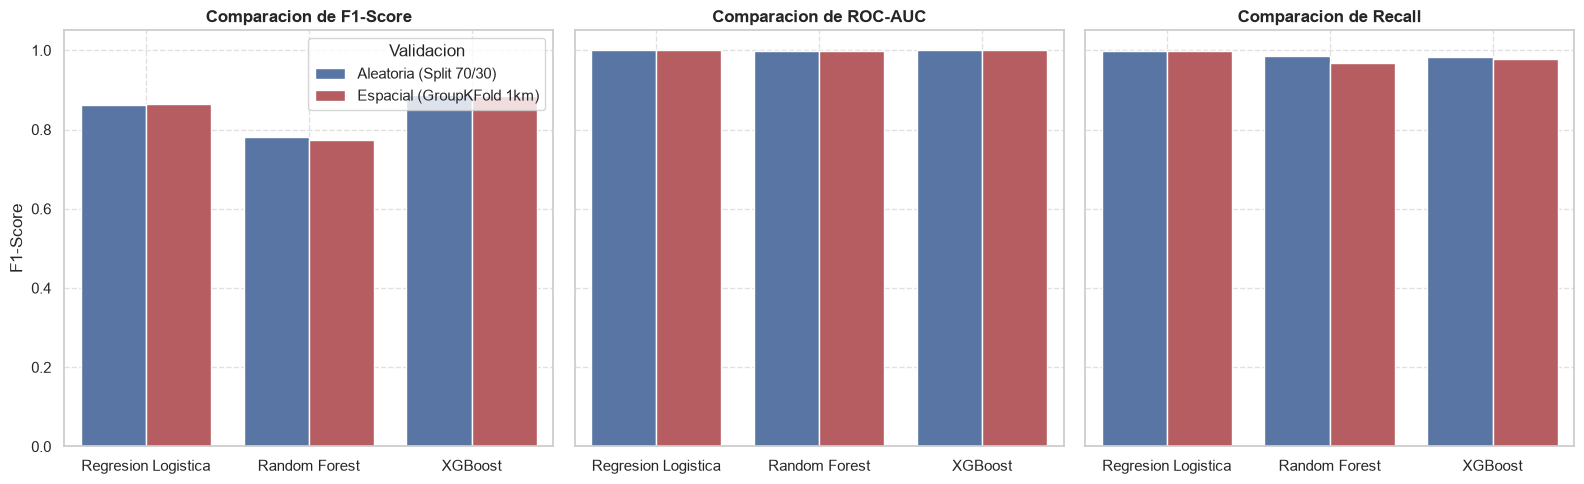

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
metricas_plot = ['F1-Score', 'ROC-AUC', 'Recall']

for ax, met in zip(axes, metricas_plot):
    sns.barplot(
        data=df_comparacion_completa,
        x='Modelo',
        y=met,
        hue='Validacion',
        palette=['#4C72B0', '#C44E52'],
        ax=ax
    )
    ax.set_title(f'Comparacion de {met}', fontsize=12, fontweight='bold')
    ax.set_ylabel(met if ax == axes[0] else '')
    ax.set_xlabel('')
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.6)
    if ax != axes[0]:
        ax.legend_.remove()

plt.tight_layout()
plt.show()


### 6.6 Qué nos dice la comparación

**La caída es mínima.**

| Modelo | F1 aleatorio | F1 espacial | Diferencia |
|---|---|---|---|
| Regresión Logística | 0.8623 | 0.8637 | +0.0014 |
| Random Forest | 0.7802 | 0.7727 | -0.0075 |
| XGBoost | 0.8874 | 0.8850 | -0.0024 |

Ningún modelo pierde un punto de F1. Random Forest baja algo en Recall, de 0.9851 a 0.9671, y los otros dos se quedan igual.

**Por qué esperábamos una caída.** Por la primera ley de Tobler, las cosas cercanas se parecen más entre sí. En una división aleatoria por píxeles, un píxel de prueba está a 20 metros de uno de entrenamiento, así que el modelo puede acertar por vecindad. Agrupar por bloques de 1 km cierra esa ruta.

**Por qué no cayó.** La cuadrícula separa vecindarios dentro de un lago, pero **los dos lagos siguen presentes en entrenamiento y validación en todos los folds**. Como muestra el ejercicio 8, el modelo se apoya en `y_utm`, que funciona como identificador de lago y da directamente la probabilidad base (0.21% contra 15.56%). Esa pista sobrevive intacta a la partición por bloques, así que nunca se pone a prueba.

Dicho eso, el ejercicio 8 también muestra que el modelo no necesitaba esa pista: al reentrenar sin coordenadas el F1 no baja. Las dos cosas son ciertas a la vez, tomó un atajo posicional y aun sin él habría funcionado igual.

**Cuál estimación creemos.** La espacial, con la advertencia de que resultó una prueba poco exigente. Separar el espacio dentro de un lago no era el punto débil de este modelo; la validación temporal y la transferencia entre lagos sí lo encuentran.

### 6.7 Validación temporal

La validación por bloques responde qué tan bien predice el modelo sobre una bahía que no vio. Falta la otra mitad: qué tan bien predice sobre una **fecha** que no vio, que es la pregunta que importa para un sistema de alerta. En operación el modelo se entrena con las imágenes que existen y se aplica a la que baja mañana, así que nunca tiene ejemplos del futuro.

Usamos `TimeSeriesSplit` sobre las 19 fechas ordenadas cronológicamente, con ventana expansiva: cada fold entrena con todas las fechas anteriores a un corte y valida sobre las tres siguientes. El entrenamiento siempre está en el pasado de la validación.

In [32]:
def crear_modelos(y_entrenamiento):
    """Devuelve los tres modelos sin entrenar, con scale_pos_weight ajustado al fold."""
    peso_positivo = (len(y_entrenamiento) - y_entrenamiento.sum()) / max(1, y_entrenamiento.sum())
    return {
        'Regresion Logistica': clone(lr_pipeline),
        'Random Forest': clone(rf_clf),
        'XGBoost': XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=peso_positivo, tree_method='hist',
            random_state=42, n_jobs=-1
        ),
    }

def evaluar_modelo(modelo, X_val, y_val):
    y_pred = modelo.predict(X_val)
    y_proba = modelo.predict_proba(X_val)[:, 1]
    return {
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall': recall_score(y_val, y_pred, zero_division=0),
        'F1-Score': f1_score(y_val, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_val, y_proba) if len(np.unique(y_val)) > 1 else np.nan,
    }

fechas_ordenadas = np.sort(df_ml['fecha'].unique())
print(f'Fechas distintas disponibles: {len(fechas_ordenadas)}')

tscv = TimeSeriesSplit(n_splits=4)
composicion_folds = []
particiones_temporales = []

for fold, (idx_tr, idx_va) in enumerate(tscv.split(fechas_ordenadas), start=1):
    fechas_tr = fechas_ordenadas[idx_tr]
    fechas_va = fechas_ordenadas[idx_va]
    mascara_tr = df_ml['fecha'].isin(fechas_tr).values
    mascara_va = df_ml['fecha'].isin(fechas_va).values
    particiones_temporales.append((fold, mascara_tr, mascara_va))
    composicion_folds.append({
        'Fold': fold,
        'Fechas entrenamiento': len(fechas_tr),
        'Pixeles entrenamiento': mascara_tr.sum(),
        'Fechas validacion': len(fechas_va),
        'Pixeles validacion': mascara_va.sum(),
        'Positivos validacion': int(y[mascara_va].sum()),
        '% positivos validacion': round(y[mascara_va].mean() * 100, 2),
        'Validacion desde': str(pd.Timestamp(fechas_va[0]).date()),
        'Validacion hasta': str(pd.Timestamp(fechas_va[-1]).date()),
    })

print('Composicion de los folds temporales (ventana expansiva)')
display(pd.DataFrame(composicion_folds).set_index('Fold'))

Fechas distintas disponibles: 19
Composicion de los folds temporales (ventana expansiva)


,Fechas entrenamiento,Pixeles entrenamiento,Fechas validacion,Pixeles validacion,Positivos validacion,% positivos validacion,Validacion desde,Validacion hasta
Fold,,,,,,,,
1,7,97607,3,26657,783,2.94,2025-11-24,2026-01-08
2,10,124264,3,24436,86,0.35,2026-02-02,2026-02-12
3,13,148700,3,50251,392,0.78,2026-03-24,2026-04-13
4,16,198951,3,51048,2911,5.70,2026-04-28,2026-07-22


In [33]:
resultados_temporales = {'Regresion Logistica': [], 'Random Forest': [], 'XGBoost': []}

print('Ejecutando validacion temporal (4 folds cronologicos)...')
for fold, mascara_tr, mascara_va in particiones_temporales:
    X_tr_t, y_tr_t = X[mascara_tr], y[mascara_tr]
    X_va_t, y_va_t = X[mascara_va], y[mascara_va]

    for nombre, modelo in crear_modelos(y_tr_t).items():
        modelo.fit(X_tr_t, y_tr_t)
        resultados_temporales[nombre].append(evaluar_modelo(modelo, X_va_t, y_va_t))
    print(f'  Fold {fold}/4 listo')

df_res_temporal = pd.DataFrame({
    nombre: pd.DataFrame(metricas).mean() for nombre, metricas in resultados_temporales.items()
}).T

print('\nMetricas promedio de la validacion temporal')
display(df_res_temporal.round(4))

f1_por_fold = pd.DataFrame(
    {nombre: [m['F1-Score'] for m in metricas] for nombre, metricas in resultados_temporales.items()},
    index=[f'Fold {i}' for i in range(1, 5)]
)
print('F1-Score fold por fold')
display(f1_por_fold.round(4))

Ejecutando validacion temporal (4 folds cronologicos)...


  Fold 1/4 listo


  Fold 2/4 listo


  Fold 3/4 listo


  Fold 4/4 listo

Metricas promedio de la validacion temporal


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Regresion Logistica,0.9919,0.6803,0.9968,0.7637,0.9969
Random Forest,0.9816,0.5825,0.8605,0.6265,0.9919
XGBoost,0.9893,0.6725,0.8305,0.7031,0.9966


F1-Score fold por fold


,Regresion Logistica,Random Forest,XGBoost
Fold 1,0.7955,0.6035,0.7471
Fold 2,0.3320,0.1810,0.3880
Fold 3,0.9469,0.7947,0.7858
Fold 4,0.9805,0.9269,0.8916


Las tres estrategias de validacion, lado a lado


,Modelo,Estrategia,Precision,Recall,F1-Score,ROC-AUC
0,Regresion Logistica,Aleatoria (70/30),0.7582,0.9993,0.8623,0.9998
1,Regresion Logistica,Espacial (bloques 1 km),0.7605,0.9994,0.8637,0.9997
2,Regresion Logistica,Temporal (por fecha),0.6803,0.9968,0.7637,0.9969
3,Random Forest,Aleatoria (70/30),0.6459,0.9851,0.7802,0.9991
4,Random Forest,Espacial (bloques 1 km),0.6439,0.9671,0.7727,0.9985
5,Random Forest,Temporal (por fecha),0.5825,0.8605,0.6265,0.9919
6,XGBoost,Aleatoria (70/30),0.8092,0.9823,0.8874,0.9997
7,XGBoost,Espacial (bloques 1 km),0.8093,0.9771,0.8850,0.9995
8,XGBoost,Temporal (por fecha),0.6725,0.8305,0.7031,0.9966


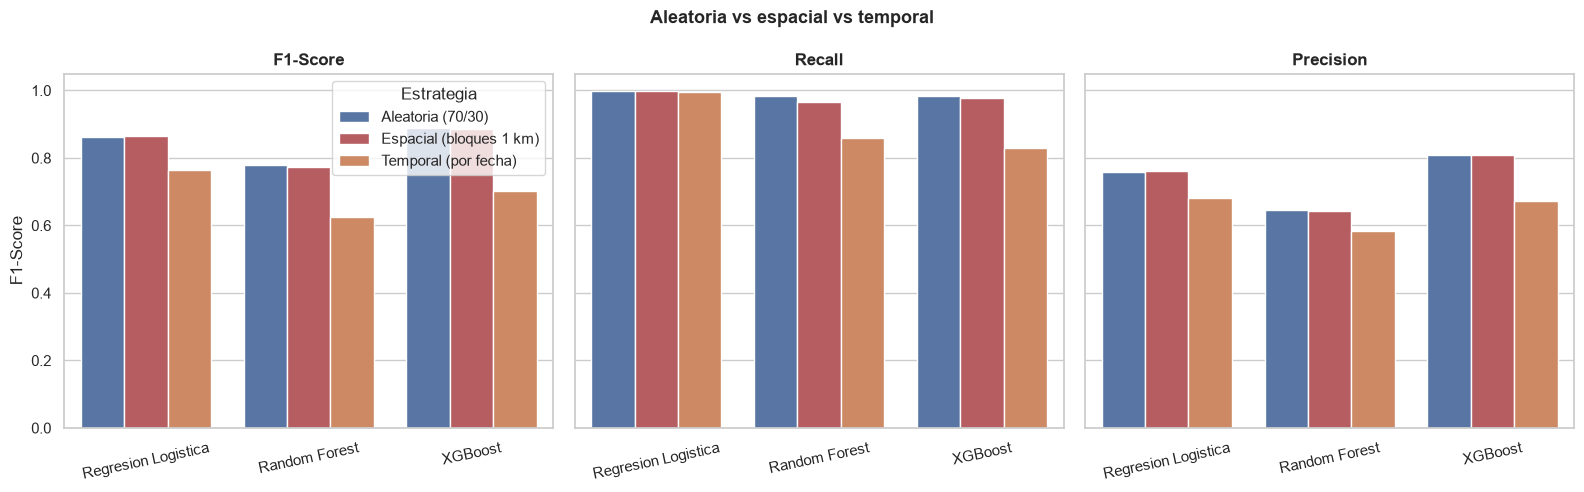

In [34]:
filas_estrategias = []
for mod in ['Regresion Logistica', 'Random Forest', 'XGBoost']:
    filas_estrategias.append({'Modelo': mod, 'Estrategia': 'Aleatoria (70/30)',
                              'Precision': df_metricas_test.loc[mod, 'Precision (Clase 1)'],
                              'Recall': df_metricas_test.loc[mod, 'Recall (Clase 1)'],
                              'F1-Score': df_metricas_test.loc[mod, 'F1-Score (Clase 1)'],
                              'ROC-AUC': df_metricas_test.loc[mod, 'ROC-AUC']})
    for etiqueta, tabla in [('Espacial (bloques 1 km)', df_res_espacial),
                            ('Temporal (por fecha)', df_res_temporal)]:
        filas_estrategias.append({'Modelo': mod, 'Estrategia': etiqueta,
                                  'Precision': tabla.loc[mod, 'Precision'],
                                  'Recall': tabla.loc[mod, 'Recall'],
                                  'F1-Score': tabla.loc[mod, 'F1-Score'],
                                  'ROC-AUC': tabla.loc[mod, 'ROC-AUC']})

df_estrategias = pd.DataFrame(filas_estrategias)
print('Las tres estrategias de validacion, lado a lado')
display(df_estrategias.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, met in zip(axes, ['F1-Score', 'Recall', 'Precision']):
    sns.barplot(data=df_estrategias, x='Modelo', y=met, hue='Estrategia',
                palette=['#4C72B0', '#C44E52', '#DD8452'], ax=ax)
    ax.set_title(met, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(met if ax is axes[0] else '')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=12)
    if ax is not axes[0]:
        ax.legend_.remove()
plt.suptitle('Aleatoria vs espacial vs temporal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.7.1 Qué muestra la validación temporal

**Aquí sí hay caída, y es la mayor del laboratorio.**

| Modelo | F1 aleatorio | F1 espacial | F1 temporal | Caída |
|---|---|---|---|---|
| Regresión Logística | 0.8623 | 0.8637 | 0.7637 | -0.0986 |
| Random Forest | 0.7802 | 0.7727 | 0.6265 | -0.1537 |
| XGBoost | 0.8874 | 0.8850 | 0.7031 | -0.1843 |

Separar el espacio no costó nada; separar el tiempo cuesta entre 0.10 y 0.18 puntos de F1, y el más castigado es XGBoost, el mejor bajo las otras dos validaciones. Lo que limita a este modelo no es la geografía sino el calendario.

**Los folds siguen a la prevalencia de su ventana.**

| Fold | Validación | % positivos | F1 XGBoost |
|---|---|---|---|
| 1 | 2025-11-24 a 2026-01-08 | 2.94% | 0.7471 |
| 2 | 2026-02-02 a 2026-02-12 | 0.35% | 0.3880 |
| 3 | 2026-03-24 a 2026-04-13 | 0.78% | 0.7858 |
| 4 | 2026-04-28 a 2026-07-22 | 5.70% | 0.8916 |

El fold 2 se desploma porque valida sobre febrero, con 86 píxeles positivos de 24,436: unos pocos falsos positivos hunden la precisión. El fold 4 incluye Amatitlán 2026-06-19, el evento más extenso. La ventana expansiva hace que los folds tardíos entrenen con más fechas, así que la secuencia no debe leerse como una mejora con el tiempo.

**Por qué es más dura que la espacial.** Agrupar por bloques quita el vecindario inmediato pero conserva los dos lagos y todas las fechas. Agrupar por fecha quita cosas que el modelo sí usaba: `mes` y `estacion_cod` pesan bastante por ganancia (ejercicio 8) y ante un mes nuevo dejan de servir, y se suman las diferencias de corrección atmosférica, ángulo solar y satélite entre escenas.

Para un sistema que se entrena con el histórico y predice la imagen de mañana, la referencia honesta es **0.7031**, no el 0.8874 de la división aleatoria.

## 11. Ejercicio 7: Generalización entre lagos

### 7.1 a 7.3 Los dos experimentos

Hasta aquí los modelos siempre vieron los dos lagos en entrenamiento. Ahora los separamos por completo: **Experimento A** entrena solo con Atitlán y evalúa sobre Amatitlán; **Experimento B** hace lo contrario.

Los lagos son casi opuestos. Atitlán es profundo, oligotrófico y con 0.21% de píxeles en floración; Amatitlán es somero, hipereutrófico y llega al 15.56%. Además están en lugares distintos, así que las coordenadas de un lago caen fuera del rango del otro.

In [35]:
VARIABLES_SIN_COORDENADAS = [v for v in VARIABLES_PREDICTORAS if v not in ('x_utm', 'y_utm')]

resultados_cruzados = []

for lago_entrena, lago_evalua in [('atitlan', 'amatitlan'), ('amatitlan', 'atitlan')]:
    mascara_tr = (df_ml['lago'] == lago_entrena).values
    mascara_te = (df_ml['lago'] == lago_evalua).values
    X_tr_c, y_tr_c = X[mascara_tr], y[mascara_tr]
    X_te_c, y_te_c = X[mascara_te], y[mascara_te]

    print(f'Entrena {lago_entrena} ({mascara_tr.sum():,} px, {y_tr_c.sum():,} positivos, '
          f'{y_tr_c.mean()*100:.2f}%) -> evalua {lago_evalua} ({mascara_te.sum():,} px, '
          f'{y_te_c.sum():,} positivos, {y_te_c.mean()*100:.2f}%)')

    for nombre, modelo in crear_modelos(y_tr_c).items():
        modelo.fit(X_tr_c, y_tr_c)
        fila = evaluar_modelo(modelo, X_te_c, y_te_c)
        tn, fp, fn, tp = confusion_matrix(y_te_c, modelo.predict(X_te_c)).ravel()
        fila.update({'Entrena': lago_entrena, 'Evalua': lago_evalua, 'Modelo': nombre,
                     'Predictores': '17 (con coordenadas)', 'VN': tn, 'FP': fp, 'FN': fn, 'VP': tp})
        resultados_cruzados.append(fila)

    # misma prueba quitando x_utm e y_utm, para ver cuanto pesaba la posicion
    modelo_sc = crear_modelos(y_tr_c)['XGBoost']
    modelo_sc.fit(X_tr_c[VARIABLES_SIN_COORDENADAS], y_tr_c)
    fila = evaluar_modelo(modelo_sc, X_te_c[VARIABLES_SIN_COORDENADAS], y_te_c)
    tn, fp, fn, tp = confusion_matrix(y_te_c, modelo_sc.predict(X_te_c[VARIABLES_SIN_COORDENADAS])).ravel()
    fila.update({'Entrena': lago_entrena, 'Evalua': lago_evalua, 'Modelo': 'XGBoost',
                 'Predictores': '15 (sin coordenadas)', 'VN': tn, 'FP': fp, 'FN': fn, 'VP': tp})
    resultados_cruzados.append(fila)

df_cruzado = pd.DataFrame(resultados_cruzados)[
    ['Entrena', 'Evalua', 'Modelo', 'Predictores', 'Accuracy', 'Precision', 'Recall',
     'F1-Score', 'ROC-AUC', 'VN', 'FP', 'FN', 'VP']
]
print('\nResultados de transferencia entre lagos')
display(df_cruzado.round(4))

Entrena atitlan (221,455 px, 464 positivos, 0.21%) -> evalua amatitlan (28,544 px, 4,441 positivos, 15.56%)


Entrena amatitlan (28,544 px, 4,441 positivos, 15.56%) -> evalua atitlan (221,455 px, 464 positivos, 0.21%)



Resultados de transferencia entre lagos


,Entrena,Evalua,Modelo,Predictores,Accuracy,Precision,Recall,F1-Score,ROC-AUC,VN,FP,FN,VP
0,atitlan,amatitlan,Regresion Logistica,17 (con coordenadas),0.9840,0.9075,0.9989,0.9510,0.9999,23651,452,5,4436
1,atitlan,amatitlan,Random Forest,17 (con coordenadas),0.8624,0.5955,0.3603,0.4489,0.7793,23016,1087,2841,1600
2,atitlan,amatitlan,XGBoost,17 (con coordenadas),0.8686,0.8438,0.1909,0.3114,0.8056,23946,157,3593,848
3,atitlan,amatitlan,XGBoost,15 (sin coordenadas),0.8638,0.7209,0.2036,0.3175,0.8057,23753,350,3537,904
4,amatitlan,atitlan,Regresion Logistica,17 (con coordenadas),0.9933,0.1249,0.3642,0.1860,0.9555,219807,1184,295,169
5,amatitlan,atitlan,Random Forest,17 (con coordenadas),0.9787,0.0311,0.3039,0.0565,0.7670,216604,4387,323,141
6,amatitlan,atitlan,XGBoost,17 (con coordenadas),0.9984,0.7778,0.3319,0.4653,0.9036,220947,44,310,154
7,amatitlan,atitlan,XGBoost,15 (sin coordenadas),0.9984,0.8324,0.3211,0.4635,0.9325,220961,30,315,149


XGBoost: mismo lago contra transferencia entre lagos


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Escenario,,,,,
Entrena y evalua en atitlan (70/30),0.9979,0.5020,0.9137,0.6480,0.9988
Entrena y evalua en amatitlan (70/30),0.9849,0.9318,0.9745,0.9527,0.9987
Entrena atitlan y evalua amatitlan,0.8686,0.8438,0.1909,0.3114,0.8056
Entrena amatitlan y evalua atitlan,0.9984,0.7778,0.3319,0.4653,0.9036


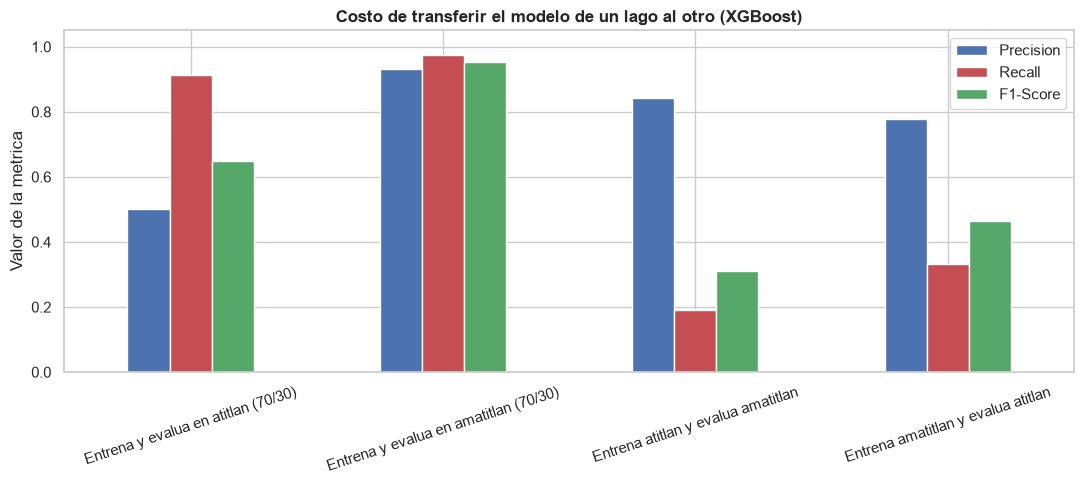

In [36]:
# Referencia: mismo lago en entrenamiento y prueba, para saber contra que comparamos
referencia_lago = []
for lago in ['atitlan', 'amatitlan']:
    mascara = (df_ml['lago'] == lago).values
    Xl, yl = X[mascara], y[mascara]
    Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(Xl, yl, test_size=0.30, random_state=42, stratify=yl)
    modelo = crear_modelos(yl_tr)['XGBoost']
    modelo.fit(Xl_tr, yl_tr)
    fila = evaluar_modelo(modelo, Xl_te, yl_te)
    fila['Escenario'] = f'Entrena y evalua en {lago} (70/30)'
    referencia_lago.append(fila)

comparacion_7 = pd.DataFrame(referencia_lago).set_index('Escenario')
transferencia = df_cruzado[(df_cruzado['Modelo'] == 'XGBoost') &
                           (df_cruzado['Predictores'] == '17 (con coordenadas)')].copy()
transferencia['Escenario'] = 'Entrena ' + transferencia['Entrena'] + ' y evalua ' + transferencia['Evalua']
comparacion_7 = pd.concat([
    comparacion_7,
    transferencia.set_index('Escenario')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
])

print('XGBoost: mismo lago contra transferencia entre lagos')
display(comparacion_7.round(4))

fig, ax = plt.subplots(figsize=(11, 5))
comparacion_7[['Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=ax,
                                                        color=['#4C72B0', '#C44E52', '#55A868'])
ax.set_title('Costo de transferir el modelo de un lago al otro (XGBoost)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor de la metrica')
ax.set_xlabel('')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=18)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 7.4 a 7.6 Qué pasó al cambiar de lago

**7.4 Contra el escenario de un solo lago (XGBoost).**

| Escenario | Precision | Recall | F1 |
|---|---|---|---|
| Entrena y evalúa en Atitlán | 0.5020 | 0.9137 | 0.6480 |
| Entrena y evalúa en Amatitlán | 0.9318 | 0.9745 | 0.9527 |
| Entrena Atitlán, evalúa Amatitlán | 0.8438 | 0.1909 | 0.3114 |
| Entrena Amatitlán, evalúa Atitlán | 0.7778 | 0.3319 | 0.4653 |

En los dos cruces el Recall cae de más del 91% a entre 19% y 33%. La precisión aguanta, así que cuando marca algo suele acertar, pero se le escapa la mayoría de eventos: el peor perfil posible para un sistema de alerta.

**7.5 ¿Generaliza de un lago al otro? Depende del modelo.**

| Dirección | Reg. Logística | Random Forest | XGBoost |
|---|---|---|---|
| Atitlán a Amatitlán | **0.9510** | 0.4489 | 0.3114 |
| Amatitlán a Atitlán | 0.1860 | 0.0565 | **0.4653** |

La Regresión Logística entrenada solo con Atitlán detecta las floraciones de Amatitlán con F1 0.9510, habiendo visto apenas 464 píxeles positivos. La causa es la extrapolación: Amatitlán tiene reflectancias de borde rojo por encima de todo lo presente en Atitlán, y un árbol devuelve una constante más allá de su último corte, mientras que un modelo lineal prolonga la tendencia. Como "más borde rojo implica más clorofila" es aproximadamente monótono, esa prolongación acierta.

En la dirección contraria falla todo, y por otra razón: la prevalencia. Un umbral calibrado donde 1 de cada 6 píxeles está en floración es inservible donde la proporción es 1 de cada 480, y la Regresión Logística cae a 0.1249 de precisión.

**Las coordenadas no eran la causa.** Sin `x_utm` ni `y_utm`, XGBoost pasa de 0.3114 a 0.3175 y de 0.4653 a 0.4635. Lo que falla es el ajuste a las distribuciones espectrales y a la prevalencia, no las coordenadas fuera de rango.

**7.6 Diferencias que lo explican.**

- **Régimen trófico:** 0.21% contra 15.56% de prevalencia, así que cualquier umbral queda mal puesto en el otro lago.
- **Fondo espectral:** Atitlán es una caldera profunda de agua clara; Amatitlán es somero y turbio por el sedimento del río Villalobos. El mismo valor de reflectancia no significa lo mismo.
- **Rango dinámico:** las concentraciones de Amatitlán no ocurren en Atitlán, y ahí topan los árboles.
- **Morfometría:** casi todo Amatitlán está cerca de la orilla, mientras Atitlán tiene grandes aguas abiertas, así que `distancia_orilla_m` no es comparable.

**Conclusión práctica:** no se traslada un modelo a otro lago sin datos etiquetados de ese lago. Si hubiera que intentarlo, la evidencia favorece el modelo lineal sobre los de árboles, lo contrario de lo que sugieren las métricas dentro de un solo lago.

## 12. Ejercicio 8: Interpretabilidad del modelo

### 8.1 Importancia global de las variables

Tomamos el mejor modelo, XGBoost entrenado sobre la división 70/30, y revisamos en qué variables se apoya. La importancia por ganancia mide cuánto mejora la función de pérdida cada vez que el árbol parte por esa variable.

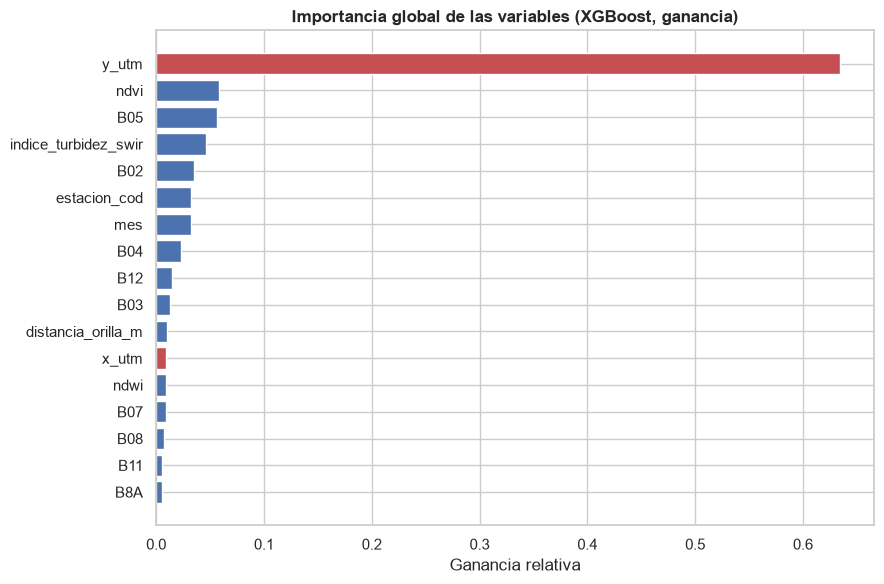

Peso de las coordenadas: 0.6435
Peso de las 9 bandas:    0.169


,Ganancia relativa
y_utm,0.6342
ndvi,0.0582
B05,0.0568
indice_turbidez_swir,0.0458
B02,0.0350
estacion_cod,0.0323
mes,0.0322
B04,0.0231
B12,0.0147
B03,0.0127


In [37]:
importancia = pd.Series(
    xgb_clf.feature_importances_, index=VARIABLES_PREDICTORAS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colores = ['#C44E52' if v in ('x_utm', 'y_utm') else '#4C72B0' for v in importancia.index]
ax.barh(importancia.index[::-1], importancia.values[::-1], color=colores[::-1])
ax.set_title('Importancia global de las variables (XGBoost, ganancia)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ganancia relativa')
plt.tight_layout()
plt.show()

print('Peso de las coordenadas:', round(importancia[['x_utm', 'y_utm']].sum(), 4))
print('Peso de las 9 bandas:   ', round(importancia[BANDAS].sum(), 4))
display(importancia.round(4).to_frame('Ganancia relativa'))

### 8.2 SHAP

La importancia por ganancia dice cuánto usa el modelo cada variable, pero no en qué dirección. SHAP reparte cada predicción entre las variables que la empujaron hacia arriba o hacia abajo, así que sí muestra el signo.

Calculamos los valores sobre una muestra del conjunto de prueba. Con la proporción natural de clases casi todos los puntos serían negativos y el gráfico no mostraría nada, así que sobrerrepresentamos la clase positiva a propósito: tomamos hasta 1,500 píxeles con floración y 6,000 sin ella.

Muestra para SHAP: 7,472 pixeles (1,472 con floracion alta)


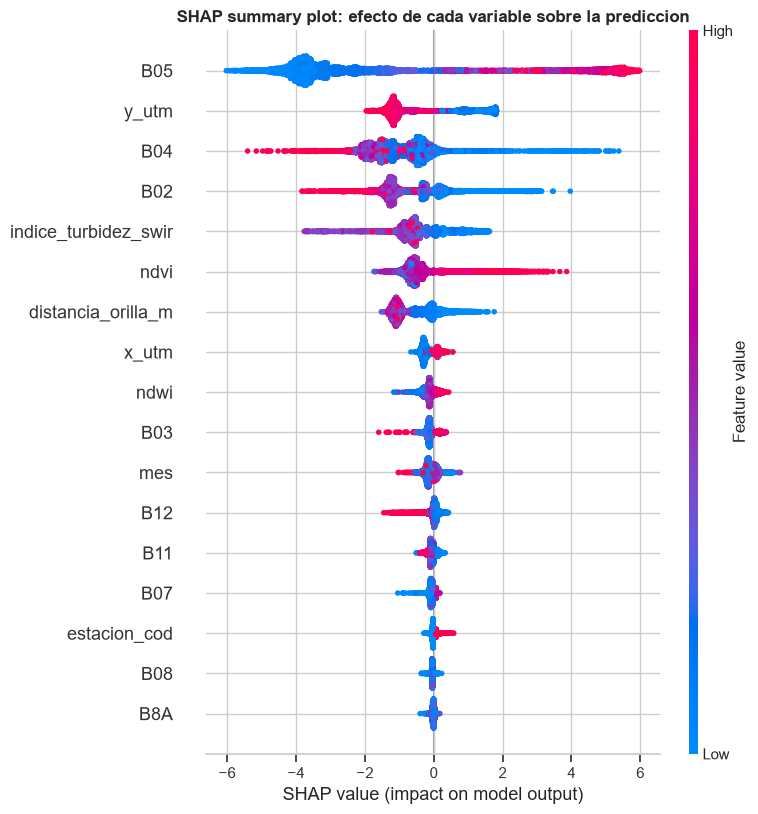

In [38]:
import shap

generador = np.random.RandomState(42)
indices_pos = X_test.index[y_test == 1]
indices_neg = X_test.index[y_test == 0]
muestra_shap = np.concatenate([
    generador.choice(indices_pos, min(1500, len(indices_pos)), replace=False),
    generador.choice(indices_neg, min(6000, len(indices_neg)), replace=False),
])
X_shap = X_test.loc[muestra_shap]
print(f'Muestra para SHAP: {len(X_shap):,} pixeles '
      f'({int(y_test.loc[muestra_shap].sum()):,} con floracion alta)')

explicador = shap.TreeExplainer(xgb_clf)
valores_shap = explicador.shap_values(X_shap)

shap.summary_plot(valores_shap, X_shap, max_display=17, show=False)
plt.title('SHAP summary plot: efecto de cada variable sobre la prediccion',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
# Las dos medidas de importancia no ordenan igual las variables
comparacion_importancia = pd.DataFrame({
    'SHAP medio |valor|': np.abs(valores_shap).mean(axis=0),
    'Ganancia': xgb_clf.feature_importances_,
}, index=VARIABLES_PREDICTORAS)
comparacion_importancia['Puesto SHAP'] = comparacion_importancia['SHAP medio |valor|'].rank(ascending=False).astype(int)
comparacion_importancia['Puesto ganancia'] = comparacion_importancia['Ganancia'].rank(ascending=False).astype(int)
comparacion_importancia = comparacion_importancia.sort_values('SHAP medio |valor|', ascending=False)

print('Importancia por ganancia frente a importancia por SHAP')
display(comparacion_importancia.round(4))

correlacion_rangos = comparacion_importancia['SHAP medio |valor|'].corr(
    comparacion_importancia['Ganancia'], method='spearman')
print(f'Correlacion de Spearman entre los dos ordenamientos: {correlacion_rangos:.3f}')

Importancia por ganancia frente a importancia por SHAP


,SHAP medio |valor|,Ganancia,Puesto SHAP,Puesto ganancia
B05,3.4178,0.0568,1,3
y_utm,1.1695,0.6342,2,1
B04,1.1377,0.0231,3,8
B02,0.9361,0.0350,4,5
indice_turbidez_swir,0.6762,0.0458,5,4
ndvi,0.6678,0.0582,6,2
distancia_orilla_m,0.6668,0.0097,7,11
x_utm,0.2203,0.0093,8,12
ndwi,0.1724,0.0092,9,13
B03,0.1498,0.0127,10,10


Correlacion de Spearman entre los dos ordenamientos: 0.740


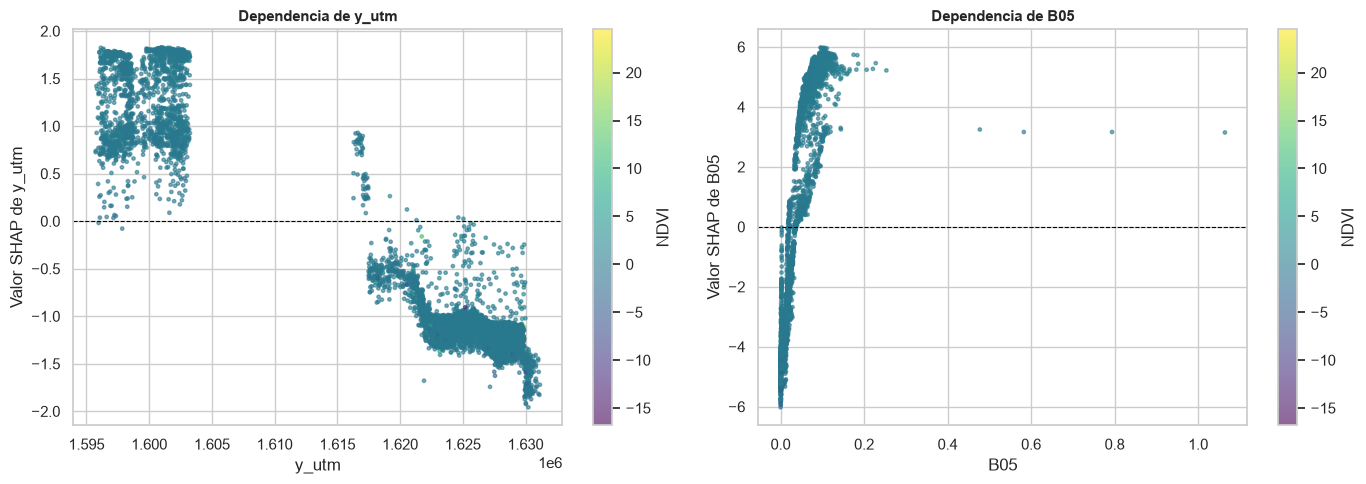

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, variable in zip(axes, ['y_utm', 'B05']):
    posicion = VARIABLES_PREDICTORAS.index(variable)
    puntos = ax.scatter(X_shap[variable], valores_shap[:, posicion],
                        c=X_shap['ndvi'], cmap='viridis', s=6, alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(variable)
    ax.set_ylabel(f'Valor SHAP de {variable}')
    ax.set_title(f'Dependencia de {variable}', fontsize=11, fontweight='bold')
    plt.colorbar(puntos, ax=ax, label='NDVI')

plt.tight_layout()
plt.show()

In [41]:
# Cuanto costaria prescindir de las coordenadas en la division aleatoria
xgb_sin_coords = crear_modelos(y_train)['XGBoost']
xgb_sin_coords.fit(X_train[VARIABLES_SIN_COORDENADAS], y_train)

comparacion_coords = pd.DataFrame({
    'Con coordenadas (17)': evaluar_modelo(xgb_clf, X_test, y_test),
    'Sin coordenadas (15)': evaluar_modelo(xgb_sin_coords, X_test[VARIABLES_SIN_COORDENADAS], y_test),
}).T

print('XGBoost con y sin coordenadas, mismo conjunto de prueba')
display(comparacion_coords.round(4))

XGBoost con y sin coordenadas, mismo conjunto de prueba


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Con coordenadas (17),0.9951,0.8092,0.9823,0.8874,0.9997
Sin coordenadas (15),0.9952,0.8075,0.9891,0.8892,0.9997


### 8.3 y 8.4 Qué muestran los resultados

**Las dos medidas de importancia no ordenan igual.** Por ganancia, `y_utm` domina con cerca del 63%, más de tres veces lo que suman las nueve bandas. Por SHAP medio, `B05` queda primera y `y_utm` segunda con menos de la mitad de su peso. La correlación de Spearman entre ambos ordenamientos es 0.74.

No es contradicción. La ganancia premia los cortes cercanos a la raíz, y `y_utm` hace exactamente eso: un corte separa los dos lagos y elimina de golpe buena parte de la incertidumbre, porque las prevalencias son 0.21% y 15.56%. Hecha esa separación, quien decide píxel por píxel es `B05`, que es lo que mide SHAP. En resumen, **`y_utm` sirve para ubicarse y `B05` para decidir**.

**El atajo no era necesario.** Sin coordenadas, el F1 pasa de 0.8874 a 0.8892 y el Recall de 0.9823 a 0.9891. Esto explica por qué la validación por bloques del ejercicio 6 resultó poco exigente: nunca puso a prueba la pista que el modelo usaba para ubicarse. En retrospectiva, las coordenadas no debieron incluirse en un modelo entrenado con dos lagos a la vez.

**Las direcciones del SHAP tienen sentido físico.**

| Variable | Valores altos empujan hacia | Por qué |
|---|---|---|
| `B05` (borde rojo) | Floración | Es donde la clorofila deja su firma. |
| `B04` (rojo) | Sin floración | Es el pico de absorción: mucha reflectancia implica poca clorofila. |
| `B02` (azul) | Sin floración | El agua limpia dispersa azul; los pigmentos lo absorben. |
| `ndvi` | Floración | Sube cuando la biomasa flotante responde como vegetación. |
| `indice_turbidez_swir` | Sin floración | Separa turbidez mineral de la causada por algas. |
| `distancia_orilla_m` | Sin floración | Los nutrientes entran por la costa. |
| `y_utm` | Sin floración | Atitlán está al norte y es el lago de prevalencia baja. |

Que las siete coincidan con lo esperado desde la limnología indica que el modelo no explota artefactos de la imagen. La única sin mecanismo físico es `y_utm`, justamente la que el ejercicio 7 muestra que no ayuda a generalizar. En el gráfico de dependencia, `y_utm` forma un escalón entre los rangos de cada lago mientras que `B05` crece de forma continua.

**El calendario pesa por ganancia y casi nada por SHAP.** `estacion_cod` y `mes` sirven para cortes gruesos pero no para afinar predicciones individuales, y son lo que penaliza la validación temporal.

## 13. Ejercicio 9: Mapas predictivos

Aplicamos XGBoost píxel por píxel sobre una fecha de cada lago y devolvemos las probabilidades a su posición original en la imagen, usando `fila_px` y `col_px`. Elegimos:

- **Amatitlán, 2026-06-19:** la floración más extensa de toda la serie, con 76.6% del lago por encima del umbral.
- **Atitlán, 2025-11-21:** la fecha con más área en floración de ese lago, aunque apenas llega al 1% de la superficie.

Aquí se predice sobre todos los píxeles de la fecha, no sobre la muestra de 250,000.

In [42]:
NIVELES = [0.0, 0.25, 0.50, 0.75, 1.0]
ETIQUETAS_NIVEL = ['Muy baja (< 0.25)', 'Baja (0.25 a 0.50)', 'Alta (0.50 a 0.75)', 'Muy alta (>= 0.75)']
COLORES_NIVEL = ['#2c7bb6', '#abd9e9', '#fdae61', '#d7191c']

def mapa_predictivo(lago, fecha):
    """Predice la fecha completa y devuelve las mallas 2D de probabilidad, clorofila y error."""
    huella, _, _ = cargar_huella(lago)
    sub = df_pixeles[(df_pixeles['lago'] == lago) & (df_pixeles['fecha'] == fecha)]
    proba = xgb_clf.predict_proba(sub[VARIABLES_PREDICTORAS])[:, 1]
    prediccion = (proba >= 0.5).astype(int)
    real = sub['alta_cianobacteria'].values

    filas, columnas = sub['fila_px'].values, sub['col_px'].values
    malla_proba = np.full(huella.shape, np.nan, dtype=np.float32)
    malla_chla = np.full(huella.shape, np.nan, dtype=np.float32)
    malla_error = np.full(huella.shape, np.nan, dtype=np.float32)

    malla_proba[filas, columnas] = proba
    malla_chla[filas, columnas] = sub['chla'].values
    # 0 = acierto negativo, 1 = acierto positivo, 2 = falso positivo, 3 = falso negativo
    codigo = np.where((real == 1) & (prediccion == 1), 1,
             np.where((real == 0) & (prediccion == 1), 2,
             np.where((real == 1) & (prediccion == 0), 3, 0)))
    malla_error[filas, columnas] = codigo
    return sub, proba, real, prediccion, malla_proba, malla_chla, malla_error

mapas = {}
for lago, fecha in [('amatitlan', '2026-06-19'), ('atitlan', '2025-11-21')]:
    mapas[(lago, fecha)] = mapa_predictivo(lago, pd.Timestamp(fecha))
    sub, proba, real, pred, _, _, _ = mapas[(lago, fecha)]
    print(f'{lago} {fecha}: {len(sub):,} pixeles | reales en floracion {real.sum():,} | '
          f'predichos {pred.sum():,} | Recall {recall_score(real, pred, zero_division=0):.4f} | '
          f'Precision {precision_score(real, pred, zero_division=0):.4f}')

amatitlan 2026-06-19: 34,436 pixeles | reales en floracion 26,380 | predichos 28,763 | Recall 0.9981 | Precision 0.9154


atitlan 2025-11-21: 287,610 pixeles | reales en floracion 2,862 | predichos 5,058 | Recall 0.9196 | Precision 0.5204


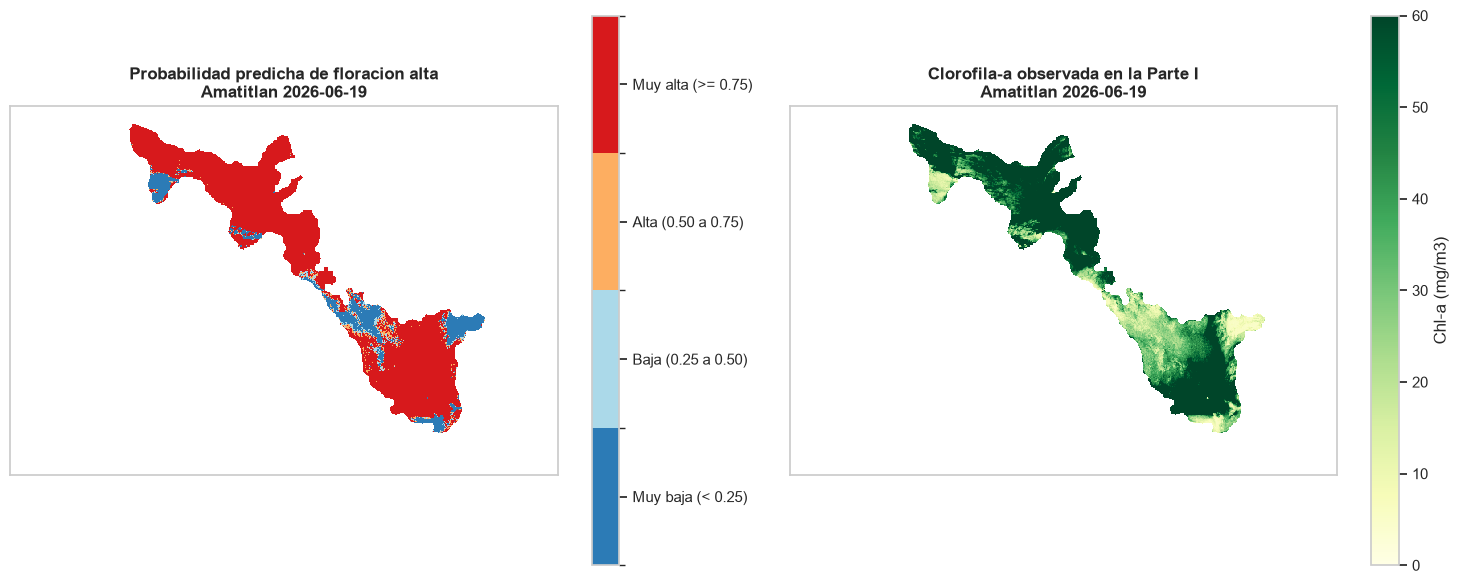

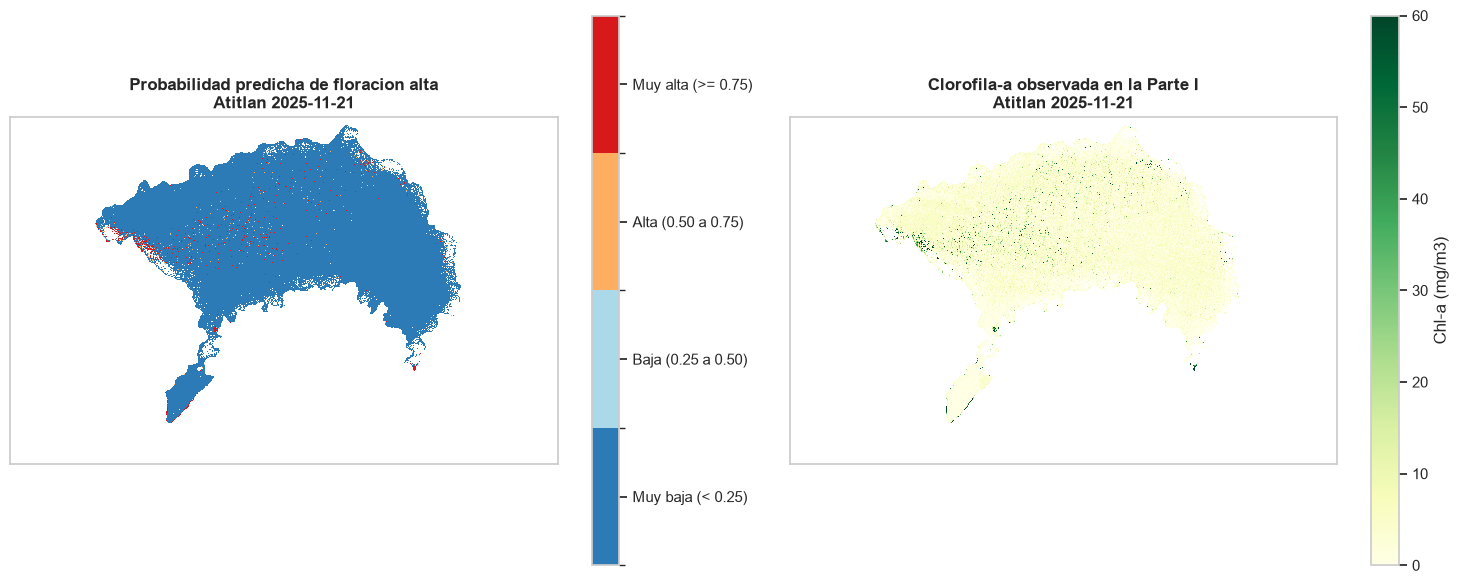

In [43]:
cmap_niveles = ListedColormap(COLORES_NIVEL)
norm_niveles = BoundaryNorm(NIVELES, cmap_niveles.N)

for (lago, fecha), (sub, proba, real, pred, malla_proba, malla_chla, malla_error) in mapas.items():
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    im0 = axes[0].imshow(malla_proba, cmap=cmap_niveles, norm=norm_niveles, interpolation='nearest')
    axes[0].set_title(f'Probabilidad predicha de floracion alta\n{lago.capitalize()} {fecha}',
                      fontsize=12, fontweight='bold')
    barra = plt.colorbar(im0, ax=axes[0], boundaries=NIVELES, ticks=[0.125, 0.375, 0.625, 0.875])
    barra.ax.set_yticklabels(ETIQUETAS_NIVEL)

    im1 = axes[1].imshow(malla_chla, cmap='YlGn', vmin=0, vmax=60, interpolation='nearest')
    axes[1].set_title(f'Clorofila-a observada en la Parte I\n{lago.capitalize()} {fecha}',
                      fontsize=12, fontweight='bold')
    plt.colorbar(im1, ax=axes[1], label='Chl-a (mg/m3)')

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    plt.show()

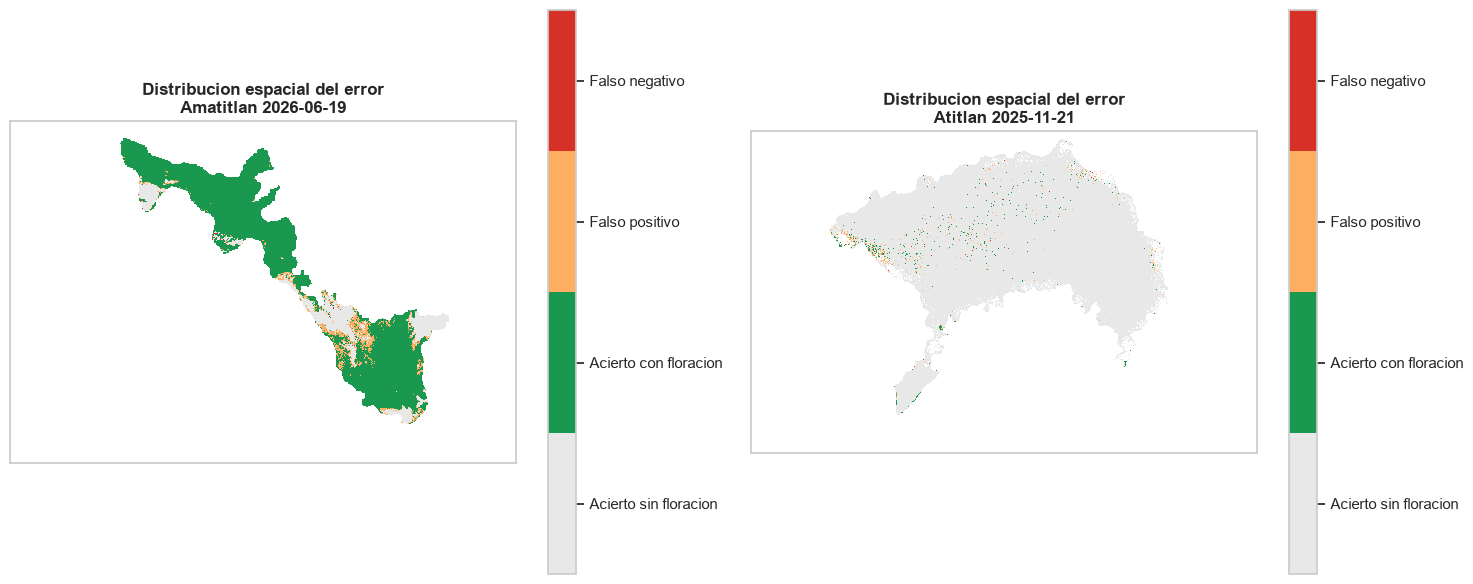

In [44]:
cmap_error = ListedColormap(['#e8e8e8', '#1a9850', '#fdae61', '#d73027'])
etiquetas_error = ['Acierto sin floracion', 'Acierto con floracion', 'Falso positivo', 'Falso negativo']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, ((lago, fecha), datos) in zip(axes, mapas.items()):
    malla_error = datos[6]
    im = ax.imshow(malla_error, cmap=cmap_error, vmin=-0.5, vmax=3.5, interpolation='nearest')
    ax.set_title(f'Distribucion espacial del error\n{lago.capitalize()} {fecha}',
                 fontsize=12, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    barra = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
    barra.ax.set_yticklabels(etiquetas_error)
plt.tight_layout()
plt.show()

In [45]:
resumen_mapas = []
for (lago, fecha), (sub, proba, real, pred, _, _, _) in mapas.items():
    tn, fp, fn, tp = confusion_matrix(real, pred).ravel()
    niveles = pd.cut(proba, NIVELES, labels=ETIQUETAS_NIVEL, include_lowest=True)
    conteo = niveles.value_counts().reindex(ETIQUETAS_NIVEL)
    resumen_mapas.append({
        'Lago': lago, 'Fecha': fecha, 'Pixeles': len(sub),
        'Reales en floracion': int(real.sum()), 'Predichos en floracion': int(pred.sum()),
        'VP': tp, 'FP': fp, 'FN': fn, 'VN': tn,
        'Recall': recall_score(real, pred, zero_division=0),
        'Precision': precision_score(real, pred, zero_division=0),
        'F1-Score': f1_score(real, pred, zero_division=0),
        **{f'Nivel {e.split(" (")[0]}': int(conteo[e]) for e in ETIQUETAS_NIVEL},
    })
print('Resumen por mapa')
display(pd.DataFrame(resumen_mapas).set_index(['Lago', 'Fecha']).T)

# Donde se equivoca: distancia a la orilla segun el tipo de acierto o error
patron_error = []
for (lago, fecha), (sub, proba, real, pred, _, _, _) in mapas.items():
    tipo = np.select(
        [(real == 1) & (pred == 1), (real == 0) & (pred == 1), (real == 1) & (pred == 0)],
        ['Acierto con floracion', 'Falso positivo', 'Falso negativo'], 'Acierto sin floracion')
    tabla = pd.DataFrame({'tipo': tipo, 'distancia': sub['distancia_orilla_m'].values})
    resumen = tabla.groupby('tipo')['distancia'].agg(['count', 'mean', 'median']).round(1)
    resumen.insert(0, 'Lago', lago)
    patron_error.append(resumen)

print('\nDistancia a la orilla (m) segun el tipo de acierto o error')
display(pd.concat(patron_error))

Resumen por mapa


Lago,amatitlan,atitlan
Fecha,2026-06-19,2025-11-21
Pixeles,34436.000000,287610.000000
Reales en floracion,26380.000000,2862.000000
Predichos en floracion,28763.000000,5058.000000
VP,26331.000000,2632.000000
FP,2432.000000,2426.000000
FN,49.000000,230.000000
VN,5624.000000,282322.000000
Recall,0.998143,0.919637
Precision,0.915447,0.520364



Distancia a la orilla (m) segun el tipo de acierto o error


,Lago,count,mean,median
tipo,,,,
Acierto con floracion,amatitlan,26331,284.1,240.0
Acierto sin floracion,amatitlan,5624,194.6,161.2
Falso negativo,amatitlan,49,169.4,169.7
Falso positivo,amatitlan,2432,239.3,170.9
Acierto con floracion,atitlan,2632,1208.9,756.4
Acierto sin floracion,atitlan,282322,1346.3,1193.6
Falso negativo,atitlan,230,812.3,363.6
Falso positivo,atitlan,2426,937.7,466.9


### 9.5 a 9.7 Lectura de los mapas

**El mapa reproduce la forma de la floración.** La probabilidad predicha y la clorofila-$a$ de la Parte I coinciden en extensión y ubicación de los parches. En Amatitlán 2026-06-19 el lago aparece cubierto casi por completo (27,867 de 34,436 píxeles en probabilidad muy alta); en Atitlán 2025-11-21 el centro queda en probabilidad muy baja (281,141 píxeles) y el riesgo se concentra en parches costeros.

| | Amatitlán 2026-06-19 | Atitlán 2025-11-21 |
|---|---|---|
| Recall | 0.9981 | 0.9196 |
| Precision | 0.9154 | 0.5204 |
| F1 | 0.9550 | 0.6646 |
| Falsos positivos | 2,432 | 2,426 |
| Falsos negativos | 49 | 230 |

**El número absoluto de falsos positivos es casi idéntico en ambos lagos,** unos 2,430. Lo que cambia es contra qué se comparan: en Amatitlán hay 26,380 positivos reales y son ruido menor; en Atitlán hay 2,862 y la misma cantidad de errores arrasa con la precisión. Es el desbalance de clases visto sobre el mapa.

**El error se concentra cerca de la orilla.** En Atitlán la mediana de distancia a la costa es 364 m para falsos negativos y 467 m para falsos positivos, contra 1,194 m para los aciertos sin floración. En Amatitlán los errores caen cerca de 170 m y los aciertos con floración a 240 m.

**Dónde falla sistemáticamente:** franja costera y bahías cerradas. A 20 metros de resolución esa franja mezcla agua, vegetación ribereña y fondo somero en una celda, así que el NDCI no mide solo clorofila. Como la etiqueta también sale del NDCI, ahí fallan a la vez la predicción y la referencia: parte de lo que contamos como error del modelo es ruido de la etiqueta.

## 14. Ejercicio 10: Análisis y conclusiones

F1-Score de cada modelo bajo cada estrategia de validacion


Modelo,Random Forest,Regresion Logistica,XGBoost
Estrategia,,,
Aleatoria (70/30),0.7802,0.8623,0.8874
Entre lagos (amatitlan a atitlan),0.0565,0.1860,0.4653
Entre lagos (atitlan a amatitlan),0.4489,0.9510,0.3114
Espacial (bloques 1 km),0.7727,0.8637,0.8850
Temporal (por fecha),0.6265,0.7637,0.7031


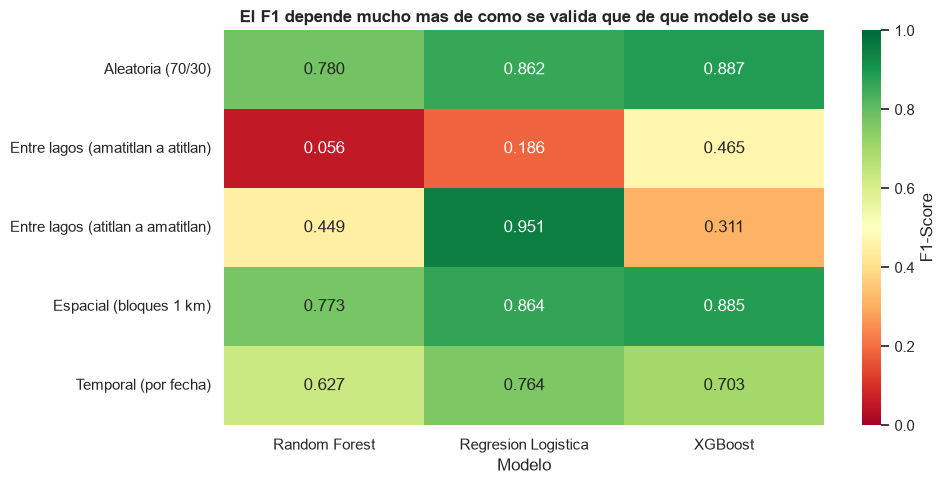

In [46]:
consolidado = df_estrategias.copy()

filas_extra = []
for _, fila in df_cruzado[df_cruzado['Predictores'] == '17 (con coordenadas)'].iterrows():
    filas_extra.append({'Modelo': fila['Modelo'],
                        'Estrategia': f"Entre lagos ({fila['Entrena']} a {fila['Evalua']})",
                        'Precision': fila['Precision'], 'Recall': fila['Recall'],
                        'F1-Score': fila['F1-Score'], 'ROC-AUC': fila['ROC-AUC']})

consolidado = pd.concat([consolidado, pd.DataFrame(filas_extra)], ignore_index=True)
tabla_final = consolidado.pivot_table(index='Estrategia', columns='Modelo', values='F1-Score')

print('F1-Score de cada modelo bajo cada estrategia de validacion')
display(tabla_final.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(tabla_final, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label': 'F1-Score'}, ax=ax)
ax.set_title('El F1 depende mucho mas de como se valida que de que modelo se use',
             fontsize=12, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 10.1 ¿Sirve el modelo para apoyar el monitoreo?

**Sí en Amatitlán, con reservas en Atitlán, y en ningún caso como emisor automático de alertas.**

- **Amatitlán:** XGBoost llega a F1 0.9527 con Recall 0.9745 dentro del lago, y el mapa del 2026-06-19 reproduce la extensión real con Recall 0.9981.
- **Atitlán:** Recall 0.9137 pero precisión 0.5020, o sea que la mitad de las alertas son falsas. Sirve como filtro para decidir dónde muestrear, porque reduce 287,610 píxeles a unos 5,000 candidatos, no para un aviso público sin verificación.
- **Entre lagos:** XGBoost, el mejor dentro de un lago, es el peor transfiriendo (0.3114), mientras la Regresión Logística alcanza 0.9510 en esa dirección. No se puede soltar el modelo en un lago nuevo sin verificar.
- **En el tiempo:** F1 0.7031 promediando folds cronológicos contra 0.8874 con división aleatoria, y 0.3880 en el peor fold. Ese es el techo real.

La conclusión metodológica principal: **la diferencia entre estrategias de validación es mayor que la diferencia entre modelos**. El F1 de XGBoost se mueve entre 0.3114 y 0.8874 según cómo se valide, un rango mucho mayor que el que separa a los tres algoritmos bajo una misma validación. Quedarse con la división aleatoria habría dado una impresión bastante más optimista.

### 10.2 Limitaciones

- **La etiqueta no es medición de campo.** Sale de umbralizar la clorofila estimada por NDCI, nunca contrastada contra laboratorio. Entrenamos un modelo para reproducir otro modelo y heredamos sus errores. Es la limitación de fondo.
- **Pocas fechas:** 21 escenas útiles, folds temporales de tres fechas, y el fold 2 con solo 86 píxeles positivos.
- **Resolución de 20 m:** los errores se concentran donde un píxel mezcla agua, vegetación y fondo; las floraciones incipientes no son resolubles.
- **Sesgo estacional:** las escenas nubladas se descartan y abundan en época lluviosa, justo cuando hay más arrastre de nutrientes.
- **Desbalance extremo en Atitlán:** con 0.21% de positivos, la precisión queda estructuralmente castigada.
- **Coordenadas entre los predictores:** `y_utm` se llevó el 63% de la ganancia como identificador de lago y quitarla no costó desempeño.
- **Los árboles no extrapolan:** ante reflectancias fuera del rango de entrenamiento, Random Forest y XGBoost fallan sin avisar.

### 10.3 Qué mejoraría el modelo

- **Datos de campo:** muestreos de clorofila y conteo celular para calibrar el NDCI localmente y validar la etiqueta. Es lo que más aportaría, porque ataca la limitación de fondo.
- **Variables meteorológicas:** temperatura del aire, precipitación acumulada previa y viento. Las floraciones responden a agua caliente, superficie calmada y pulsos de nutrientes tras las lluvias, y nada de eso está en la imagen del día. El laboratorio sugiere las series de weatherspark.
- **Temperatura superficial del agua** desde el infrarrojo térmico de Landsat 8 y 9, uno de los mejores predictores en la literatura.
- **Historia reciente del píxel:** el estado de la escena anterior en el mismo punto, disponible en operación real.
- **Más escenas,** filtrando por píxel válido en lugar de descartar la fecha completa, para recuperar imágenes parcialmente nubladas.
- **Batimetría y uso del suelo de la cuenca,** que explican dónde se acumula la biomasa y de dónde viene la carga de nutrientes.